**Министерство науки и высшего образования Российской Федерации**

ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ 
УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

**НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

**ITMO University**

# Лабораторная работа №1

### Численные методы в линейной алгебре и решении нелинейных уравнений

**Авторы работы**

- Галстян Артём Артакович (465503)
- Сакулин Иван Михайлович (467335)
- Сафронов Иван Сергеевич (467380)

**Руководитель**

- Попов Арсений Михайлович



# Введение

**Цель работы**: Изучение и сравнение точных и итерационных методов решения систем линейных алгебраических уравнений, а также методов решения нелинейных уравнений и систем. Проведение численных экспериментов, оценка точности, устойчивости и сходимости.

In [558]:
import time
import warnings
from typing import Callable

from IPython.display import Math, Markdown

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# Точные методы решения СЛАУ

- Метод Гаусса с частичным выбором главного элемента
- LU-разложение
- Разложение Холецкого для симметричных положительно определённых матриц

### (1) Метод Гаусса с частичным выбором ведущего элемента

##### Краткое описание

**Прямой ход:** 
- Сводим матрицу к верхнетреугольному виду
- Для повышения точности переупорядочиваем строки, выбирая максимальный по модулю

**Обратный ход:**
- Начиная с низа матрицы, определяем неизвестные
- Последовательно переходим к верхним уравнениям

**Формула обратного хода**

Для системы с верхнетреугольной матрицей \( U \), решение вычисляется по формуле:

$$x_i = \frac{b_i - \sum_{j=i+1}^{n} u_{ij} \cdot x_j}{u_{ii}}, \quad i = n, n-1, \ldots, 1$$

где:
- $x_i$ - искомая переменная
- $u_{ij}$ - элементы верхнетреугольной матрицы
- $b_i$ - элементы правой части системы
- $n$ - размерность системы

##### Реализация

Для красивого вывода генерируем целыми числами

In [559]:
def solve_gaussian(matrix, result):
    # Узнаём размерность матрицы
    n = len(result)
    # Дополняем матрицу до расширенной
    Ab = np.hstack([matrix.astype(float), result.reshape(-1, 1).astype(float)])
    
    # Перебираем строки в поисках главного элемента
    for i in range(n):
        # Выбираем наибольший по модулю элемент
        max_row = np.argmax(np.abs(Ab[i:, i])) + i
        if max_row != i:
            Ab[[i, max_row]] = Ab[[max_row, i]]
        
        # перебираем остальные строки и приводим матрицу к верхнетреугольному виду.
        for j in range(i + 1, n):
            k = Ab[j, i] / Ab[i, i]
            Ab[j, i:] -= k * Ab[i, i:]
    
    # Создаём вектор из нулей
    answer = np.zeros(n)
    for i in range(n-1, -1, -1):
        # Вычмсляем значения и решаем СЛАУ
        answer[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], answer[i+1:n])) / Ab[i, i]
    
    # Округляем до целых чисел и преобразуем к целому типу
    return np.round(answer).astype(int)

def generate_slau(n, seed=47):
    #генерация матрицы по сиду, чтобы иметь возможность повторно увидеть какой-либо результат
    np.random.seed(seed)
    A = np.random.randint(-10, 11, (n, n))
    # Генерация коеффициентов
    for i in range(n):
        A[i, i] = np.sum(np.abs(A[i, :])) + 1
    # Генерация значений переменных
    x_true = np.random.randint(-5, 6, n)
    # Формирование слобца с ответами
    b = (A @ x_true).astype(int)
    return A, b, x_true

##### Проверка при $n = 10$, при $n = 50$

In [560]:
print("Проверка при n = 10:")
A, b, x_true = generate_slau(10)
print("\nA:\n", A)
print("\nb:\n", b)
ans = solve_gaussian(A, b)
print("\nans:\n", ans)
print("\nx_true\n", x_true)

print("*"*50)

print("\nПроверка при n = 50:")
A, b, x_true = generate_slau(50)
print("\nA:\n", A)
print("\nb:\n", b)
ans = solve_gaussian(A, b)
print("\nans:\n", ans)
print("\nx_true\n", x_true)

print("*"*50)

print("Корректность работы:", all(x_true == ans))

Проверка при n = 10:

A:
 [[ 42  -4  -3  -2  -2   9   6   6  -3  -3]
 [  3  58   8   8   1  -9  10  -2  -1   8]
 [ -1  -9  61  -1  -8 -10  -8   4   7  -6]
 [ -7  10  -5  52  -4   5  -9   9   1   0]
 [  0   1  -1   3  45  -7  -6   2   9  -9]
 [ 10  10   1  -8  -8  66  -1   6  -9  -6]
 [  6   5  -4  -4   8   8  50  -2   2   2]
 [-10  -6  10   3  -4  10   3  58   3  -1]
 [ -2  -9  -3   6   4   7   1  -1  46   4]
 [ -8  -3  -2  -2   1  -2  -8   9   1  47]]

b:
 [ 115 -252 -170 -181  235 -215 -185  -76 -156 -139]

ans:
 [ 3 -3 -4 -3  4 -4 -4  1 -3 -4]

x_true
 [ 3 -3 -4 -3  4 -4 -4  1 -3 -4]
**************************************************

Проверка при n = 50:

A:
 [[254  -4  -3 ...   2   9  -9]
 [ 10 263   1 ...   9   1  10]
 [ -2  -8 264 ...  -1   9   4]
 ...
 [ -2   0  -7 ... 274  10   8]
 [  7   0  10 ...  -5 260  -3]
 [ -7 -10  -7 ...  -3  -7 253]]

b:
 [ -262 -1152  1287   -18   316  -301  -283  -438   489  1309   796  -453
  1033 -1277  -813 -1167  -591  -403  -601   529  -174   1

### (2) LU-разложение

##### Краткое описание

**LU-разложение** - это представление матрицы A в виде произведения двух матриц:
- **L** (Lower) - нижняя треугольная матрица с единицами на диагонали
- **U** (Upper) - верхняя треугольная матрица

**Формула:** A = L × U

**Преимущества:**
- Один раз разложив матрицу, можно быстро решать системы с разными правыми частями
- Упрощает вычисление определителя и обратной матрицы
- Более эффективно чем многократное применение метода Гаусса

**Алгоритм:**
1. Инициализировать L как единичную матрицу, U как нулевую
2. Для каждого элемента матрицы:
   - Если элемент на/выше диагонали → вычисляем U[i,j]
   - Если элемент ниже диагонали → вычисляем L[i,j]

##### Реализация

In [561]:
def lu_decomposition(A):
    n = A.shape[0]          # Размерность матрицы
    L = np.eye(n)           # Инициализация L как единичной матрицы
    U = np.zeros((n, n))    # Инициализация U как нулевой матрицы
    
    # Проход по всем элементам матрицы
    for i in range(n):
        for j in range(n):
            if j >= i:
                # Вычисление элементов U (верхний треугольник и диагональ)
                U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
            if i > j:
                # Вычисление элементов L (нижний треугольник)
                L[i, j] = (A[i, j] - np.dot(L[i, :j], U[:j, j])) / U[j, j]
    
    return L, U

def solve_lu(A, b):
    try:
        # Выполняем LU-разложение матрицы A
        L, U = lu_decomposition(A)
        # Проверка диагональных элементов U на вырожденность
        for i in range(U.shape[0]):
            if abs(U[i, i]) < 1e-12:
                raise ValueError("Нулевой диагональный элемент")
        
        # Прямая подстановка: решение системы L*y = b
        n = len(b)
        y = np.zeros(n)  # Вектор промежуточных переменных
        y[0] = b[0] / L[0, 0]
        # Остальные уравнения: для k от 1 до n-1
        for k in range(1, n):
            y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]
        
        # Обратная подстановка: решение системы U*x = y
        x = np.zeros(n)  # Вектор решения
        # Последнее уравнение
        x[-1] = y[-1] / U[-1, -1]
        # Остальные уравнения: для k от n-2 до 0 (снизу вверх)
        for k in range(n-2, -1, -1):
            x[k] = (y[k] - np.dot(U[k, k+1:], x[k+1:])) / U[k, k]
        
        return x
        
    except ValueError as e:
        # Обработка ошибки при вырожденной матрице
        print("Ошибка LU-разложения:", e)
        return None
    

##### Проверка

In [562]:
# Тестовая матрица и вектор правой части
A = np.array([
    [1, 3, 3],
    [4, 5, 6],
    [7, 8, 10]
], dtype=float)

b = np.array([1, 2, 3], dtype=float)

print("Исходная матрица A:\n", A)
print("\nВектор b:\n", b)

# Решение системы LU-разложением
answer = solve_lu(A, b)
print("\nВычисление:\n", answer)

Исходная матрица A:
 [[ 1.  3.  3.]
 [ 4.  5.  6.]
 [ 7.  8. 10.]]

Вектор b:
 [1. 2. 3.]

Вычисление:
 [ 1.  2. -2.]


### (3) Разложение Холецкого

##### Краткое описание

**Принцип:** A = L × Lᵀ  
где L - нижняя треугольная матрица

**Цель:** Эффективное решение симметричных положительно определенных систем

**Преимущества:**
- В 2 раза быстрее LU-разложения
- Гарантированно устойчиво
- Проще вычислять определитель

**Ограничение:** Только для симметричных положительно определенных матриц

##### Реализация

In [563]:
# Разложение Холецкого для симметричной положительно определенной матрицы A = L * L^T
def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1):
            if i == j:
                # Диагональные элементы
                sum_sq = np.sum(L[i, :j]**2)
                L[i, j] = np.sqrt(A[i, i] - sum_sq)
            else:
                # Недиагональные элементы
                sum_prod = np.sum(L[i, :j] * L[j, :j])
                L[i, j] = (A[i, j] - sum_prod) / L[j, j]
    
    return L

def is_symmetric_positive_definite(A):
    # Проверка симметричности
    if not np.allclose(A, A.T):
        return False, "матрица не симметричная"
    # Проверка положительной определенности через собственные значения
    eigenvalues = np.linalg.eigvals(A)
    if np.any(eigenvalues <= 0):
        return False, "матрица не положительно определена"
    return True, "матрица подходит для разложения Холецкого"

def solve_cholesky(A, b):
    # Выполняем разложение Холецкого
    L = cholesky_decomposition(A)

    # Прямая подстановка
    n = len(b)
    y = np.zeros(n)
    # Первое уравнение
    y[0] = b[0] / L[0, 0]
    # Остальные уравнения: для k от 1 до n-1
    for k in range(1, n):
        y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]

    # Обратная подстановка
    x = np.zeros(n)
    # Последнее уравнение
    x[-1] = y[-1] / L[-1, -1]
    # Остальные уравнения: для k от n-2 до 0 (снизу вверх)
    for k in range(n-2, -1, -1):
        x[k] = (y[k] - np.dot(L[k+1:, k], x[k+1:])) / L[k, k]
    
    return x

##### Проверка

In [564]:
# Тестовая симметричная положительно определенная матрица
A = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6]
])

# Вектор правой части
b = np.array([1, 2, 3])

print("Матрица A:\n", A)
print("\nВектор b:\n", b)

# Проверяем, подходит ли матрица для разложения Холецкого
is_valid, message = is_symmetric_positive_definite(A)
print(f"\nПроверка матрицы: {message}")

if is_valid:
    print("\n" + "*"*50)
    
    # Выполняем разложение Холецкого
    L = cholesky_decomposition(A)
    print("\nМатрица L (разложение Холецкого):\n", L)
    print("\nПроверка L * L^T:\n", L @ L.T)
    print("\nСовпадает с A:", np.allclose(L @ L.T, A))
    
    
    print("\n" + "*"*50)
    
    # Решаем СЛАУ методом Холецкого
    x = solve_cholesky(A, b)
    print("\nРешение x:\n", x)
    
    # Проверяем корректность решения
    print("\nПроверка A*x:\n", A @ x)
    print("\nДолжно быть равно b:\n", b)
    print("Проверка корректности:", np.allclose(b, A@x))
    
else:
    print("Разложение Холецкого невозможно")

Матрица A:
 [[4 1 1]
 [1 5 2]
 [1 2 6]]

Вектор b:
 [1 2 3]

Проверка матрицы: матрица подходит для разложения Холецкого

**************************************************

Матрица L (разложение Холецкого):
 [[2.         0.         0.        ]
 [0.5        2.17944947 0.        ]
 [0.5        0.80295507 2.25948294]]

Проверка L * L^T:
 [[4. 1. 1.]
 [1. 5. 2.]
 [1. 2. 6.]]

Совпадает с A: True

**************************************************

Решение x:
 [0.09278351 0.21649485 0.41237113]

Проверка A*x:
 [1. 2. 3.]

Должно быть равно b:
 [1 2 3]
Проверка корректности: True


### (4) Исследование устойчивости и чувствительность к обусловленности


##### Реализация

In [565]:
def hilbert_matrix(n):
    """ Создает матрицу Гильберта размера n x n """
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)  # Формула матрицы Гильберта
    return H

def safe_solve(method, A, b, x_true, method_name): # Обработчик ошибок
    try:
        # Вызываем метод решения СЛАУ
        x = method(A.copy(), b.copy())
        
        # Проверяем, что метод вернул результат
        if x is None:
            return "сломался", None
        
        # Вычисляем относительную ошибку решения
        error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
        
        # Проверка на разумность ошибки (отсекаем бессмысленные значения)
        if np.isnan(error) or np.isinf(error) or error > 1e10:
            return "> 1e10", None
        
        # Возвращаем отформатированную ошибку и числовое значение
        return f"{error:.2e}", error
        
    except Exception as e:
        # Ловим любые исключения и возвращаем информацию об ошибке
        return "сломался", None

def analyze_hilbert():
    #Анализ устойчивости методов на матрицах Гильберта
    sizes = [5, 7, 9, 12]  # Размеры матриц для тестирования (как в задании)
    
    print("(a) Матрицы Гильберта A = HᵀH:")
    print("n    Обусловленность   Гаусс           LU              Холецкий")
    print("*" * 70)
    
    for n in sizes:
        # Создаем матрицу Гильберта и делаем её симметричной положительно определенной
        H = hilbert_matrix(n)
        A = H.T @ H
        
        # Истинное решение (вектор из единиц)
        x_true = np.ones(n)
        # Правая часть системы
        b = A @ x_true
        
        # Вычисляем число обусловленности матрицы
        cond_A = np.linalg.cond(A)
        
        # Подавляем вывод ошибок для чистого результата
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            # Тестируем все три метода
            gauss_result, _ = safe_solve(solve_gaussian, A, b, x_true, "")
            lu_result, _ = safe_solve(solve_lu, A, b, x_true, "") 
            cholesky_result, _ = safe_solve(solve_cholesky, A, b, x_true, "")
        
        # Выводим результаты в табличном формате
        print(f"{n:<2}   {cond_A:<16.2e} {gauss_result:<15} {lu_result:<15} {cholesky_result:<15}")

def analyze_diagonally_dominant():
    # (b) Анализ методов на диагонально преобладающих матрицах
    np.random.seed(42)  # Для воспроизводимости результатов
    n = 8
    
    # Создаем случайную матрицу
    A = np.random.rand(n, n) * 2 - 1
    # Делаем матрицу диагонально преобладающей для устойчивости
    for i in range(n):
        A[i, i] = np.sum(np.abs(A[i, :])) + 10
    
    # Случайное истинное решение
    x_true = np.random.rand(n)
    # Вычисляем правую часть системы
    b = A @ x_true
    
    # Оцениваем обусловленность матрицы
    cond_A = np.linalg.cond(A)
    
    print(f"\n(b) Диагонально преобладающая матрица (n={n}, cond={cond_A:.2e}):")
    
    # Словарь методов для тестирования
    methods = {
        'Гаусс': solve_gaussian,
        'LU': solve_lu, 
        'Холецкий': solve_cholesky
    }
    
    # Тестируем каждый метод
    for name, method in methods.items():
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            result, error_val = safe_solve(method, A, b, x_true, name)
        print(f"  {name}: ошибка={result}")

def analyze_scalability():
    # (c) Исследование масштабируемости всех трёх методов
    sizes = [50, 100, 150, 200, 250, 300]  # Размеры как в задании
    
    print(f"\n(c) Масштабируемость методов (A = BᵀB + αI):")
    print("Метод        n      Время(с)    Ошибка       Обусловленность")
    print("*" * 65)
    
    # Тестируем все три метода
    methods = {
        'Гаусс': solve_gaussian,
        'LU': solve_lu,
        'Холецкий': solve_cholesky
    }
    
    for method_name, method in methods.items():
        print(f"\n{method_name}:")
        for n in sizes:
            # Создаем симметричную положительно определенную матрицу
            B = np.random.randn(n, n)
            A = B.T @ B + 0.1 * np.eye(n)
            
            # Правильное решение
            x_true = np.ones(n)
            b = A @ x_true
            
            # Оцениваем обусловленность
            cond_A = np.linalg.cond(A)
            
            # Измеряем время выполнения
            start = time.time()
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                x = method(A.copy(), b.copy())
            time_taken = time.time() - start
            
            # Проверяем успешность решения и выводим результаты
            if x is not None:
                error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
                print(f"         {n:<6} {time_taken:<10.3f} {error:<12.2e} {cond_A:<15.2e}")
            else:
                print(f"         {n:<6} {'-':<10} {'сломался':<12} {cond_A:<15.2e}")

##### (a) Тест на матрицах Гильберта

In [566]:
analyze_hilbert()

(a) Матрицы Гильберта A = HᵀH:
n    Обусловленность   Гаусс           LU              Холецкий
**********************************************************************
5    2.27e+11         0.00e+00        8.86e-06        1.38e-05       
Ошибка LU-разложения: Нулевой диагональный элемент
7    1.19e+17         9.26e-01        сломался        1.56e+00       
Ошибка LU-разложения: Нулевой диагональный элемент
9    3.52e+17         5.21e+00        сломался        1.80e+00       
Ошибка LU-разложения: Нулевой диагональный элемент
12   4.69e+18         8.82e+01        сломался        > 1e10         


##### (b) Тест на диагонально преобладающих матрицах

In [567]:
analyze_diagonally_dominant()


(b) Диагонально преобладающая матрица (n=8, cond=1.42e+00):
  Гаусс: ошибка=4.09e-01
  LU: ошибка=1.53e-16
  Холецкий: ошибка=1.10e-01


##### (c) Исследование масштабируемости всех методов

In [568]:
analyze_scalability()


(c) Масштабируемость методов (A = BᵀB + αI):
Метод        n      Время(с)    Ошибка       Обусловленность
*****************************************************************

Гаусс:
         50     0.004      0.00e+00     1.82e+03       
         100    0.013      0.00e+00     3.66e+03       
         150    0.029      0.00e+00     5.84e+03       
         200    0.068      0.00e+00     7.20e+03       
         250    0.073      0.00e+00     9.56e+03       
         300    0.103      0.00e+00     1.17e+04       

LU:
         50     0.004      1.80e-14     1.24e+03       
         100    0.016      3.19e-14     3.68e+03       
         150    0.034      6.75e-14     5.71e+03       
         200    0.062      8.55e-14     7.64e+03       
         250    0.093      1.01e-13     9.59e+03       
         300    0.136      1.98e-13     1.18e+04       

Холецкий:
         50     0.005      1.81e-14     1.98e+03       
         100    0.019      5.41e-14     3.64e+03       
         150    0.0

### (5) Исследование ошибок и зависимости от обусловленности


##### Реализация

In [569]:
def analyze_errors_and_condition():
    """
    Анализ относительной ошибки, невязки и их зависимости от числа обусловленности
    """
    print("АНАЛИЗ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ")
    print("*" * 70)
    
    # Исследуем матрицы разной размерности и обусловленности
    sizes = [3, 4, 5, 6, 7, 8]
    
    # Словари для хранения данных по методам
    method_data = {
        'Гаусс': {'conditions': [], 'errors': [], 'residuals': []},
        'LU': {'conditions': [], 'errors': [], 'residuals': []},
        'Холецкий': {'conditions': [], 'errors': [], 'residuals': []}
    }
    
    print(f"{'n':<3} {'cond(A)':<12} {'Метод':<10} {'Ошибка':<12} {'Невязка':<12} {'cond*ошибка':<12}")
    print("-" * 70)
    
    for n in sizes:
        # Создаем матрицу с контролируемой обусловленностью
        if n <= 5:
            # Для малых n используем матрицу Гильберта (плохая обусловленность)
            A = hilbert_matrix(n)
            A = A.T @ A  # Делаем SPD
        else:
            # Для больших n создаем случайную SPD матрицу
            B = np.random.randn(n, n)
            A = B.T @ B + 0.01 * np.eye(n)  # α = 0.01 для умеренной обусловленности
        
        # Истинное решение
        x_true = np.ones(n)
        b = A @ x_true
        
        # Число обусловленности
        cond_A = np.linalg.cond(A)
        
        # Тестируем методы
        methods = [
            ('Гаусс', solve_gaussian),
            ('LU', solve_lu),
            ('Холецкий', solve_cholesky)
        ]
        
        for method_name, method in methods:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                try:
                    x_calculated = method(A.copy(), b.copy())
                    
                    if x_calculated is not None:
                        # Относительная ошибка
                        relative_error = np.linalg.norm(x_calculated - x_true) / np.linalg.norm(x_true)
                        
                        # Невязка
                        residual = np.linalg.norm(A @ x_calculated - b)
                        
                        # Сохраняем результаты
                        method_data[method_name]['conditions'].append(cond_A)
                        method_data[method_name]['errors'].append(relative_error)
                        method_data[method_name]['residuals'].append(residual)
                        
                        # Выводим результаты
                        cond_error_product = cond_A * relative_error
                        print(f"{n:<3} {cond_A:<12.2e} {method_name:<10} {relative_error:<12.2e} {residual:<12.2e} {cond_error_product:<12.2e}")
                        
                except Exception as e:
                    print(f"{n:<3} {cond_A:<12.2e} {method_name:<10} {'ошибка':<12} {'-':<12} {'-':<12}")
    
    # Построение графиков
    plot_error_vs_condition(method_data)
    plot_residual_vs_error(method_data)

def plot_error_vs_condition(method_data):
    """
    Построение зависимости ошибки от числа обусловленности
    """
    plt.figure(figsize=(12, 5))
    
    # График 1: Зависимость ошибки от обусловленности
    plt.subplot(1, 2, 1)
    
    colors = {'Гаусс': 'red', 'LU': 'blue', 'Холецкий': 'green'}
    markers = {'Гаусс': 'o', 'LU': 's', 'Холецкий': '^'}
    
    for method_name, data in method_data.items():
        if data['errors'] and data['conditions']:
            # Сортируем данные по обусловленности для правильного соединения точек
            sorted_data = sorted(zip(data['conditions'], data['errors']), key=lambda x: x[0])
            conds_sorted, errors_sorted = zip(*sorted_data)
            
            plt.loglog(conds_sorted, errors_sorted, 
                      color=colors[method_name], marker=markers[method_name], 
                      label=method_name, linewidth=2, markersize=6, linestyle='-')
    
    # Теоретическая граница (cond(A) * ε_machine)
    machine_epsilon = np.finfo(float).eps
    
    # Для построения теоретической границы используем диапазон условий из данных
    all_conditions = []
    for data in method_data.values():
        all_conditions.extend(data['conditions'])
    
    if all_conditions:
        min_cond = min(all_conditions)
        max_cond = max(all_conditions)
        cond_range = np.logspace(np.log10(min_cond), np.log10(max_cond), 100)
        theoretical = cond_range * machine_epsilon
        plt.loglog(cond_range, theoretical, 'k--', 
                  label=f'Теор. граница (cond·ε)', alpha=0.7, linewidth=1.5)
    
    plt.xlabel('Число обусловленности ν₂(A)', fontsize=12)
    plt.ylabel('Относительная ошибка ∥x−x*∥₂/∥x*∥₂', fontsize=12)
    plt.title('Зависимость ошибки от обусловленности', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # График 2: Отношение ошибки к обусловленности
    plt.subplot(1, 2, 2)
    
    ratios_data = []
    labels = []
    
    for method_name, data in method_data.items():
        if data['errors'] and data['conditions']:
            ratios = []
            for cond, error in zip(data['conditions'], data['errors']):
                if error > 0:
                    ratios.append(error / cond)
            
            if ratios:
                ratios_data.append(ratios)
                labels.append(method_name)
    
    if ratios_data:
        plt.boxplot(ratios_data, labels=labels)
        plt.axhline(y=machine_epsilon, color='r', linestyle='--', 
                   label=f'ε_machine = {machine_epsilon:.1e}', alpha=0.7)
        plt.ylabel('Ошибка / ν₂(A)', fontsize=12)
        plt.title('Отношение ошибки к обусловленности', fontsize=14)
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Нет данных для построения', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Отношение ошибки к обусловленности\n(нет данных)', fontsize=14)
    
    plt.tight_layout()
    plt.show()

def plot_residual_vs_error(method_data):
    """
    Построение зависимости невязки от ошибки
    """
    plt.figure(figsize=(10, 6))
    
    colors = {'Гаусс': 'red', 'LU': 'blue', 'Холецкий': 'green'}
    markers = {'Гаусс': 'o', 'LU': 's', 'Холецкий': '^'}
    
    for method_name, data in method_data.items():
        if data['errors'] and data['residuals']:
            # Сортируем данные по ошибке для правильного соединения точек
            sorted_data = sorted(zip(data['errors'], data['residuals']), key=lambda x: x[0])
            errors_sorted, residuals_sorted = zip(*sorted_data)
            
            plt.loglog(errors_sorted, residuals_sorted, 
                      color=colors[method_name], marker=markers[method_name], 
                      label=method_name, linewidth=2, markersize=6, linestyle='-')
    
    plt.xlabel('Относительная ошибка ∥x−x*∥₂/∥x*∥₂', fontsize=12)
    plt.ylabel('Невязка ∥Ax−b∥₂', fontsize=12)
    plt.title('Зависимость невязки от ошибки решения', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_error_bound():
    """
    Анализ теоретической границы ошибки
    """

    print("АНАЛИЗ ТЕОРЕТИЧЕСКОЙ ГРАНИЦЫ ОШИБКИ\n")
    print("*" * 50)
    # Теоретическая оценка: ∥Δx∥/∥x∥ ≤ cond(A) * (∥ΔA∥/∥A∥ + ∥Δb∥/∥b∥)
    machine_epsilon = np.finfo(float).eps
    
    print(f"Машинная точность ε = {machine_epsilon:.1e}")
    print(f"Теоретическая граница ошибки: ∥Δx∥/∥x∥ ≤ cond(A) · ε")
    print("*" * 50)
    print("\nПримеры для различных cond(A):")
    
    
    test_conditions = [1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16]
    
    for cond in test_conditions:
        theoretical_bound = cond * machine_epsilon
        if theoretical_bound < 1e-6:
            status = "ХОРОШАЯ"
        elif theoretical_bound > 1:
            status = "ПЛОХАЯ"
        else:
            status = "УМЕРЕННАЯ"
        print(f"cond(A) = {cond:<8.1e} -> граница ошибки = {theoretical_bound:<8.1e} ({status})")

##### Анализ

In [570]:
analyze_error_bound()

АНАЛИЗ ТЕОРЕТИЧЕСКОЙ ГРАНИЦЫ ОШИБКИ

**************************************************
Машинная точность ε = 2.2e-16
Теоретическая граница ошибки: ∥Δx∥/∥x∥ ≤ cond(A) · ε
**************************************************

Примеры для различных cond(A):
cond(A) = 1.0e+02  -> граница ошибки = 2.2e-14  (ХОРОШАЯ)
cond(A) = 1.0e+04  -> граница ошибки = 2.2e-12  (ХОРОШАЯ)
cond(A) = 1.0e+06  -> граница ошибки = 2.2e-10  (ХОРОШАЯ)
cond(A) = 1.0e+08  -> граница ошибки = 2.2e-08  (ХОРОШАЯ)
cond(A) = 1.0e+10  -> граница ошибки = 2.2e-06  (УМЕРЕННАЯ)
cond(A) = 1.0e+12  -> граница ошибки = 2.2e-04  (УМЕРЕННАЯ)
cond(A) = 1.0e+14  -> граница ошибки = 2.2e-02  (УМЕРЕННАЯ)
cond(A) = 1.0e+16  -> граница ошибки = 2.2e+00  (ПЛОХАЯ)


АНАЛИЗ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ
**********************************************************************
n   cond(A)      Метод      Ошибка       Невязка      cond*ошибка 
----------------------------------------------------------------------
3   2.75e+05     Гаусс      0.00e+00     0.00e+00     0.00e+00    
3   2.75e+05     LU         1.22e-11     2.22e-16     3.36e-06    
3   2.75e+05     Холецкий   1.22e-11     2.22e-16     3.36e-06    
4   2.41e+08     Гаусс      0.00e+00     0.00e+00     0.00e+00    
4   2.41e+08     LU         7.62e-10     2.22e-16     1.83e-01    
4   2.41e+08     Холецкий   3.06e-09     2.22e-16     7.36e-01    
5   2.27e+11     Гаусс      0.00e+00     0.00e+00     0.00e+00    
5   2.27e+11     LU         8.86e-06     4.97e-16     2.01e+06    
5   2.27e+11     Холецкий   1.38e-05     7.02e-16     3.14e+06    
6   9.12e+01     Гаусс      0.00e+00     0.00e+00     0.00e+00    
6   9.12e+01     LU         5.82e-16     2.09e-15     5.31e-14    
6   9.1

C:\Users\User\AppData\Local\Temp\ipykernel_3124\56192428.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ratios_data, labels=labels)


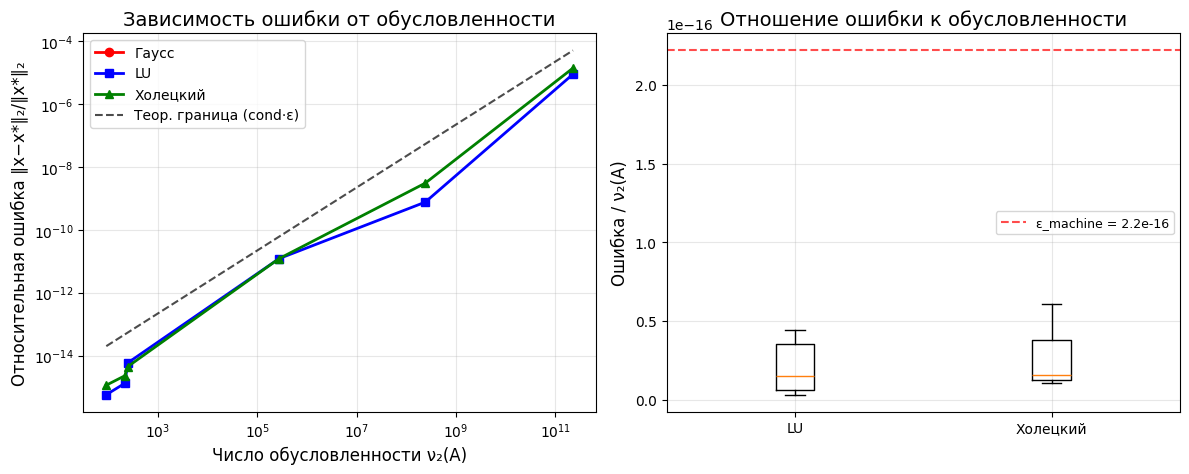

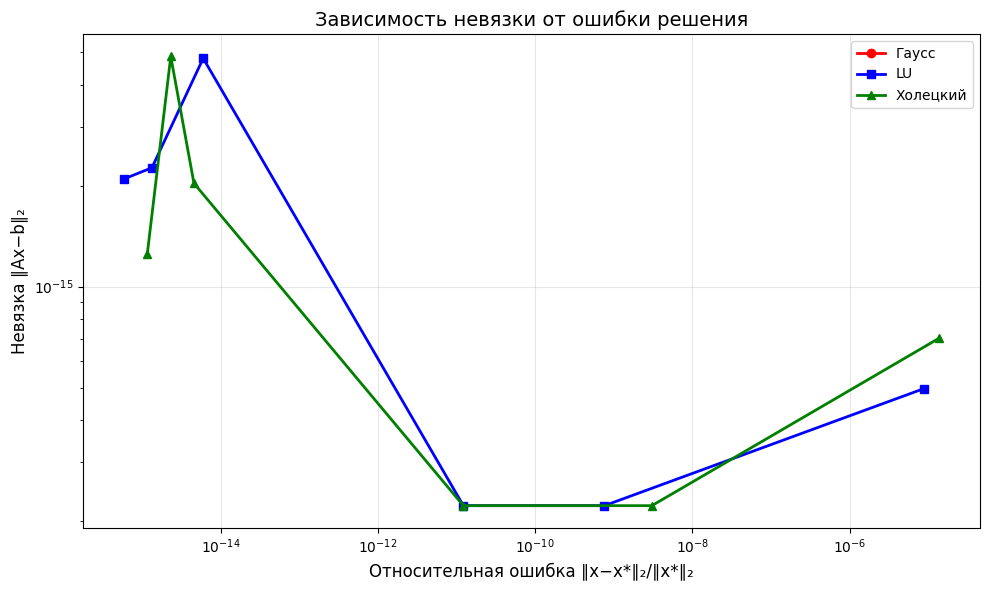

In [571]:
analyze_errors_and_condition()

# Итерационные методы решения СЛАУ

- метод Якоби
- метод Гаусса-Зейделя

Отметим, что для каждого алгоритма критерием остановки будет $\|Ax^{(k)} - b\|_2 \le 10^{-8}$

### Тестирующие функции 

In [572]:
# Для простоты назначим каждому алгоритму своё значение:
algos = {"Jacoby": 1,
         "Seidel": 0}

# Функция, которая будет выводить полезную информацию
def write_statistics(A, b, iter_x, iterations_amount, method, only_iter_and_eigenvals=False):

    # Раскладываем матрицу A на три верхнетреугольную, нижнетреугольную и диагональную
    L = np.tril(A, -1)
    D = np.diag(np.diag(A))
    U = np.triu(A, 1)

    if method == 1:
        method_name = "метод Якоби"
        B = -(np.linalg.inv(D)) @ (L + U)
    else:
        method_name = "метод Гаусса-Зейделя"
        B = -(np.linalg.inv(D + L)) @ U

    exact_x = np.linalg.solve(A, b)
    print("-----------------------------------")
    print(f"СТАТИСТИКА ({method_name}):")
    print("-----------------------------------\n")
    print("Количество итераций:", iterations_amount, end='\n\n')
    print("Максимальное по модулю собственное число матрицы B:", np.max(np.abs(np.linalg.eigvals(B))), end='\n\n')
    if not only_iter_and_eigenvals:
        print("Точное решение:", exact_x, end='\n\n')
        print("Итерационное решение", iter_x, end='\n\n')
        print("Разница итерационного и точного решений:", abs(exact_x - iter_x), end='\n\n')


# Построение графика зависимости невязки от каждой итерации
def discrepancy_vs_iteration(iterations, discrepancy, method):
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    label_name = "метод Якоби" if method == 1 else "метод Гаусса-Зейделя"
    
    # Первый график с логарифмической осью
    axs[0].plot(iterations, discrepancy, label=label_name, color="r")
    axs[0].scatter(iterations, discrepancy, label="Точные значения", color="r")
    axs[0].set_xlabel("Итерации")
    axs[0].set_ylabel("Невязка")
    axs[0].set_yscale("log")
    axs[0].set_title("График невязки (логарифм. шкала)")
    axs[0].legend()
    axs[0].grid()

    # Второй график без логарифмической оси
    axs[1].plot(iterations, discrepancy, label=label_name)
    axs[1].scatter(iterations, discrepancy, label="Точные значения")
    axs[1].set_xlabel("Итерации")
    axs[1].set_ylabel("Невязка")
    axs[1].set_title("График невязки (линейная шкала)")
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()


# построение графика нормы ошибки решения на каждой итерации
def x_k_vs_true_x(history, x_history, method):
    iterations = history[:-1, 0]
    x_final = x_history[-1]
    error_norms = np.linalg.norm(x_history[:-1] - x_final, axis=1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 строка, 2 столбца

    label_name = "метод Якоби" if method == 1 else "метод Гаусса-Зейделя"
    
    # Первый график с логарифмической осью
    axs[0].plot(iterations, error_norms, label=label_name, color="r")
    axs[0].scatter(iterations, error_norms, label="Точные значения", color="r")
    axs[0].set_xlabel("Итерации")
    axs[0].set_ylabel("Норма ошибки")
    axs[0].set_yscale("log")
    axs[0].set_title(r"График нормы ошибки решения $\|x^{(k)} - x^*\|_2$ (логарифм. шкала)")
    axs[0].legend()
    axs[0].grid()
    
    # Второй график без логарифмической оси
    axs[1].plot(iterations, error_norms, label=label_name)
    axs[1].scatter(iterations, error_norms, label="Точные значения")
    axs[1].set_xlabel("Итерации")
    axs[1].set_ylabel("Норма ошибки")
    axs[1].set_title(r"График нормы ошибки решения $\|x^{k} - x^*\|_2$")
    axs[1].legend()
    axs[1].grid()
    
    plt.tight_layout()
    plt.show()

### Метод Якоби

##### Краткое описание

Суть метода: привести матрицу $A$ и вектор $b$ к матрице $B$ и вектору $c$, вычисляемым по формулам ниже:

\begin{align}
B &= -D^{-1}\cdot (L + U)\\
c &= D^{-1} \cdot b
\end{align}
Где $L + D + U = A$ - нижнетреугольная, диагональная и верхнетреугольная части матрицы $A$ соответственно.
Далее решение ищется методом ***простой итерации***.

##### Реализация

In [573]:
import numpy as np


def jacoby_method(A, b, x0=None, max_iteration=1000, epsilon=10**-8):

    # Задаём начальное приближение
    if x0 is None:
        x = np.zeros(b.shape)
    else:
        x = x0.copy()

    
    disc = np.linalg.norm(A @ x - b) # Считаем невязку в самом начале

    # history - матрица, где в первом столбце - номер итерации, а
    # во втором - значение невязки на каждой итерации
    history = [np.array([0, disc])]

    # x_history - матрца, в строках которой записаны координаты решения на каждой итерации
    x_history = [x.copy()]

    # Разбиваем матрицу на нижне\верхне треугольную и диагональную
    # L + D + U = A
    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)

    # Согласно формулам, получаем матрицу B и вектор с
    B = -(np.linalg.inv(D)) @ (L + U)
    c = np.linalg.inv(D) @ b

    
    for iteration in range(1, max_iteration + 1):
        x = B @ x + c # Используем метод простой итерации
        disc = np.linalg.norm(A @ x - b)
        
        history.append(np.array([iteration, disc]))
        x_history.append(x.copy())
        
        if disc <= epsilon: # Проверяем критерий остановки
            return x, np.array(history), np.array(x_history), iteration

    # Если не хватило числа итераций для достижения нужной точности
    print("(Метод Якоби) Не достигнута сходимость за заданное количество итераций:", max_iteration)
    return x, np.array(history), np.array(x_history), max_iteration


##### Тест 1 (не входит в задание)

-----------------------------------
СТАТИСТИКА (метод Якоби):
-----------------------------------

Количество итераций: 30

Максимальное по модулю собственное число матрицы B: 0.49999999999999994

Точное решение: [1.71428571 1.42857143 0.42857143]

Итерационное решение [1.71428571 1.42857143 0.42857143]

Разница итерационного и точного решений: [1.59655311e-09 1.33046085e-09 3.99138000e-10]



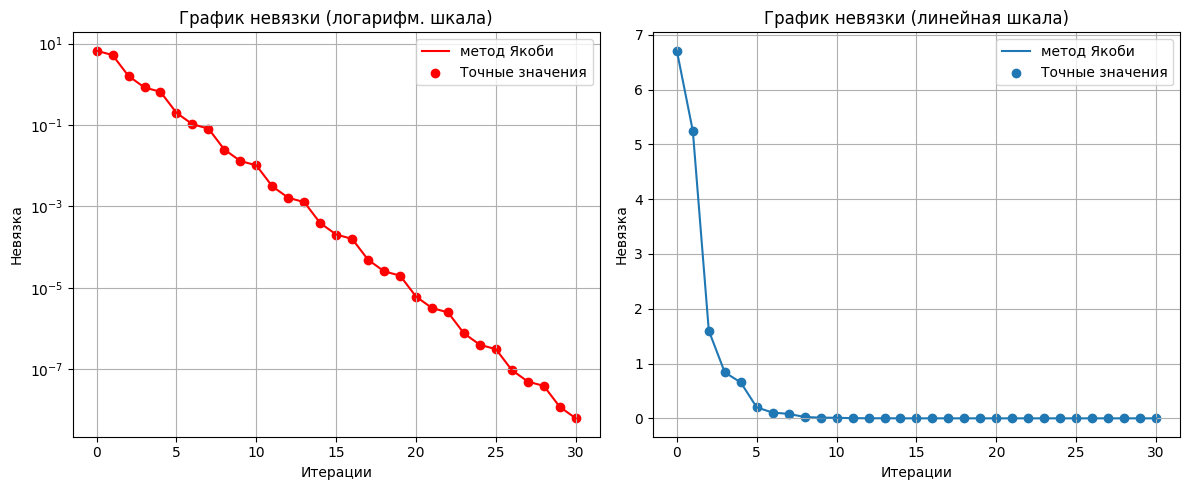

In [574]:
A = np.array([[2, -1, 0],
              [1,  2, 1],
              [1,  1, 2]])
 
b = np.array([2, 5, 4])

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Jacoby"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Jacoby"]) # Строим графики невязки

##### Тест 2 (не входит в задание)

-----------------------------------
СТАТИСТИКА (метод Якоби):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.03250526521058293

Точное решение: [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Итерационное решение [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Разница итерационного и точного решений: [4.33611480e-14 5.87585536e-14 1.31006317e-14 1.13235810e-13
 1.37667655e-14]



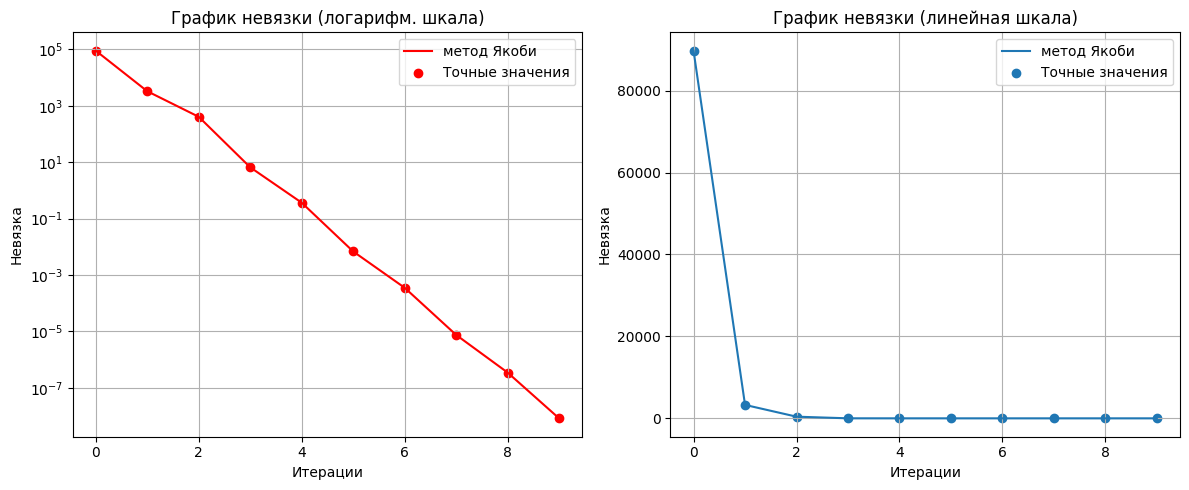

In [575]:
A = np.array([[100052, -21, 30, 715, 22],
              [112, 42431 , 402, 270, 998],
              [95,  11, 32154, 32, 241],
              [14,  5544, 21, 54542, 31],
              [54,  238, 217, 9, 31134]])

b = np.array([2311, 5345, 33128, 3574, 83124])

iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Jacoby"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Jacoby"]) # Строим графики невязки

### Метод Гаусса-Зейделя

##### Краткое описание

По сути является модификацией метода Якоби. Идея заключается в том, чтобы "не лениться" и использовать уже посчитанные значения в подсчёте следующих значений. Формулы для матрицы $B$ и $c$ выглядят следующим образом:

\begin{align}
B &= -(D + L)^{-1} U\\
c &= (D + L)^{-1} b
\end{align}

Основная фомула:
\begin{align}
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right)
\end{align}

Где $L + D + U = A$ - нижнетреугольная, диагональная и верхнетреугольная части матрицы $A$ соответственно.

##### Реализация

In [576]:
import numpy as np


def gauss_seidel_method(A, b, x0=None, max_iteration=1000, epsilon=10**-8):

    # Реализцаия до основного цикла такая же, что и в методе Якоби
    if x0 is None:
        x = np.zeros(b.shape)
    else:
        x = x0.copy()

    disc = np.linalg.norm(A @ x - b)
    history = [np.array([0, disc])]
    x_history = [x.copy()]

    D = np.diag(np.diag(A))
    L = np.tril(A, -1)
    U = np.triu(A, 1)

    B = -(np.linalg.inv(D + L)) @ U
    c = np.linalg.inv(D + L) @ b

    for iteration in range(1, max_iteration + 1):
        x_new = x.copy() # Работаем с копией вектора
        for i in range(A.shape[0]):
            sum_before_i = np.dot(A[i, :i], x_new[:i])  # до i считаем, учитывая обновлённые значения
            sum_after_i = np.dot(A[i, i + 1:], x[i + 1:])  # после i считаем, со старыми значениями
            x_new[i] = (b[i] - sum_before_i - sum_after_i) / A[i, i] # i-ая новая координата по формуле.
            
        disc = np.linalg.norm(A @ x_new - b)
        history.append(np.array([iteration, disc]))
        x_history.append(x_new.copy())
        
        if disc <= epsilon:
            return x, np.array(history), np.array(x_history), iteration
        x = x_new

    print("(Метод Гаусса-Зейделя) Не достигнута сходимость за заданное количество итераций:", max_iteration)
    return x, np.array(history), np.array(x_history), max_iteration


##### Тест 1 (не входит в задание)

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 20

Максимальное по модулю собственное число матрицы B: 0.3535533905932738

Точное решение: [1.71428571 1.42857143 0.42857143]

Итерационное решение [1.71428571 1.42857143 0.42857143]

Разница итерационного и точного решений: [5.32184341e-09 4.25747460e-09 5.32184574e-10]



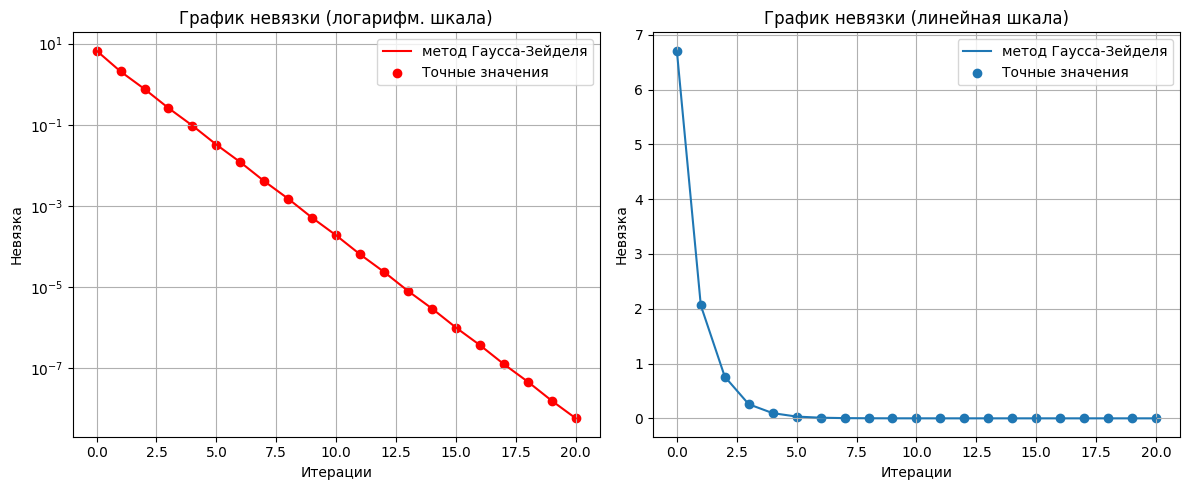

In [577]:
A = np.array([[2, -1, 0],
              [1,  2, 1],
              [1,  1, 2]])
 
b = np.array([2, 5, 4])

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Seidel"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Seidel"]) # Строим графики невязки

##### Тест 2 (не входит в задание)

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 6

Максимальное по модулю собственное число матрицы B: 0.0012412701327945807

Точное решение: [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Итерационное решение [0.02180498 0.05335004 1.01019615 0.05819688 2.66237518]

Разница итерационного и точного решений: [2.65447386e-14 3.38000461e-13 2.22044605e-15 3.46389584e-14
 2.66453526e-15]



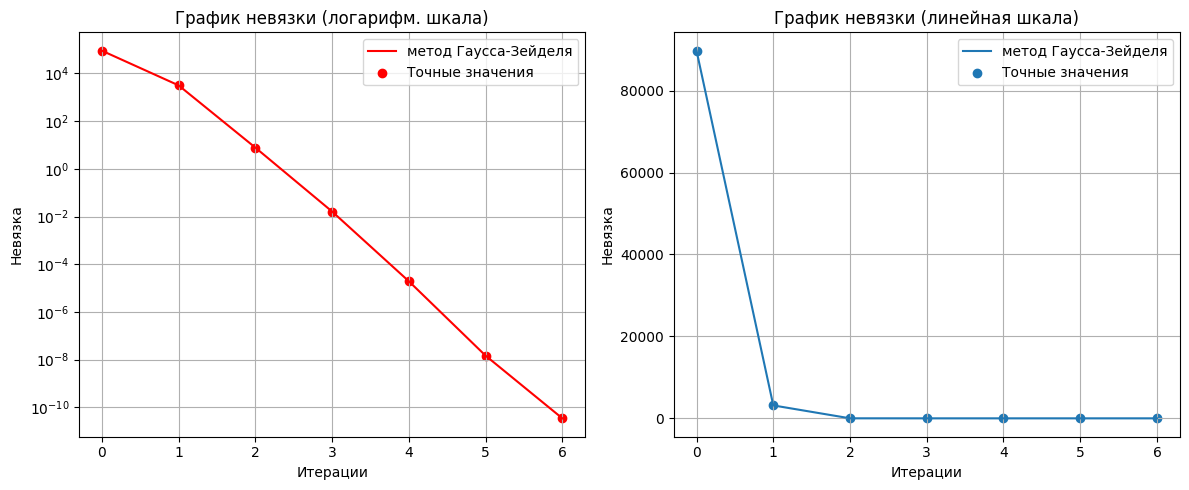

In [578]:
A = np.array([[100052, -21, 30, 715, 22],
              [112, 42431 , 402, 270, 998],
              [95,  11, 32154, 32, 241],
              [14,  5544, 21, 54542, 31],
              [54,  238, 217, 9, 31134]])

b = np.array([2311, 5345, 33128, 3574, 83124])

iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000) # Используем метод
write_statistics(A, b, iter_x, iterations_amount, method=algos["Seidel"]) # Выводим статистику
discrepancy_vs_iteration(history[:, 0], history[:, 1], method=algos["Seidel"]) # Строим графики невязки

### (2) Исследование скорости сходимости от размера системы

Для диагонально преобладающей матрицы из предыдущего раздела, используя оба метода, исследуем
зависимость скорости сходимости от размера системы и построим графики невязки $\|Ax_k - b\|_2$:

**(a)** Сравним число итераций до достижения заданной точности.

**(b)** Уменьшим диагональные элементы в 2 раза и пронаблюдаем изменение характера сходимости.

**(c)** Для положительно определённой матрицы $A = B^TB + \alpha I$ при $n = 500$.

##### (a) Сравним число итераций до достижения заданной точности.

In [579]:
np.random.seed(42)  # Для воспроизводимости результатов
n = 8

# Создаем случайную матрицу
A = np.random.rand(n, n) * 2 - 1
# Делаем матрицу диагонально преобладающей для устойчивости
for i in range(n):
    A[i, i] = np.sum(np.abs(A[i, :])) + 10

# создаём случайный вектор
b = np.random.rand(n)
print("Матрица A:\n", A, end='\n\n')
print("Вектор b:\n", b, end='\n\n')

Матрица A:
 [[ 1.48058120e+01  9.01428613e-01  4.63987884e-01  1.97316968e-01
  -6.87962719e-01 -6.88010959e-01 -8.83832776e-01  7.32352292e-01]
 [ 2.02230023e-01  1.50267740e+01 -9.58831011e-01  9.39819704e-01
   6.64885282e-01 -5.75321779e-01 -6.36350066e-01 -6.33190980e-01]
 [-3.91515514e-01  4.95128633e-02  1.26223851e+01 -4.17541720e-01
   2.23705789e-01 -7.21012279e-01 -4.15710703e-01 -2.67276313e-01]
 [-8.78600316e-02  5.70351923e-01 -6.00652436e-01  1.32533030e+01
   1.84829138e-01 -9.07099175e-01  2.15089704e-01 -6.58951753e-01]
 [-8.69896814e-01  8.97771075e-01  9.31264066e-01  6.16794696e-01
   1.49993160e+01 -8.04655772e-01  3.68466053e-01 -1.19695013e-01]
 [-7.55923530e-01 -9.64617978e-03 -9.31222958e-01  8.18640804e-01
  -4.82440037e-01  1.37396320e+01 -3.76577848e-01  4.01360424e-02]
 [ 9.34205587e-02 -6.30291089e-01  9.39169256e-01  5.50265647e-01
   8.78997883e-01  7.89654701e-01  1.49213476e+01  8.43748470e-01]
 [-8.23014996e-01 -6.08034275e-01 -9.09545422e-01 -3.4933

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 10

Максимальное по модулю собственное число матрицы B: 0.0338066500603092

Точное решение: [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Итерационное решение [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Разница итерационного и точного решений: [1.40658291e-10 1.84185306e-11 2.05909907e-11 1.01847419e-10
 5.39954474e-11 6.17768753e-11 1.47744206e-10 1.20093564e-10]



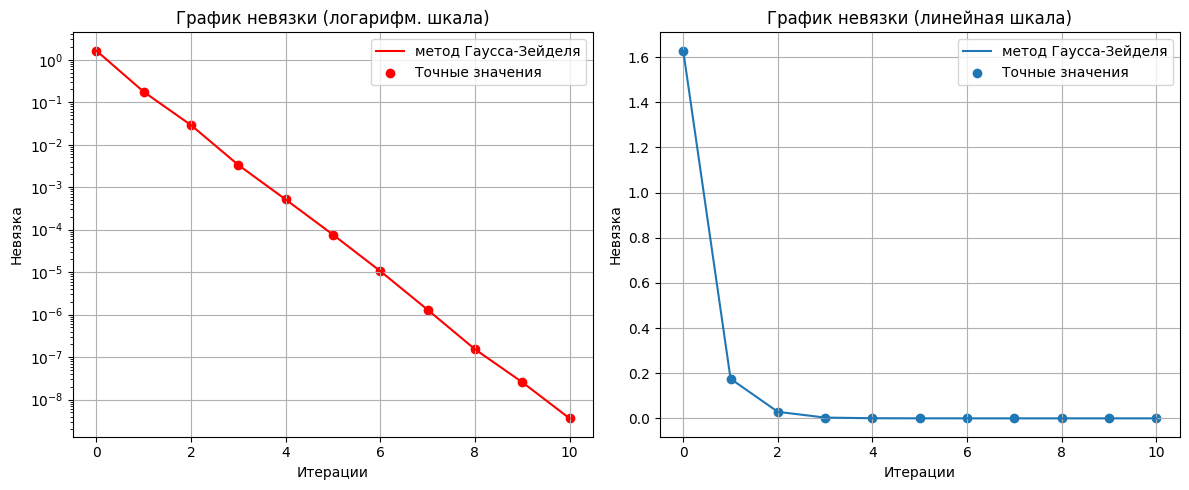

In [580]:
# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 7

Максимальное по модулю собственное число матрицы B: 0.0338066500603092

Точное решение: [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Итерационное решение [0.0202962  0.03837196 0.01972555 0.06503486 0.00286214 0.07169632
 0.0445252  0.0198103 ]

Разница итерационного и точного решений: [7.27862388e-10 1.56543119e-10 3.64018458e-10 3.97932437e-10
 1.65002798e-10 4.51172572e-11 1.20838811e-10 4.31749775e-12]



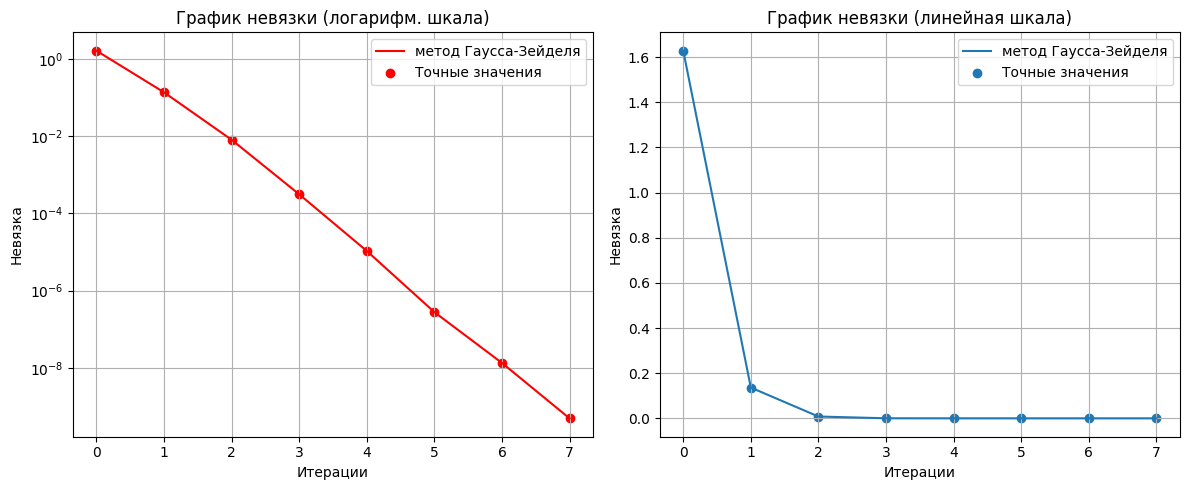

In [581]:
# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

##### (b) Уменьшим диагональные элементы в 2 раза и пронаблюдаем изменение характера сходимости.

In [582]:
# Создаем случайную матрицу
np.random.seed(42)  # Для воспроизводимости результатов
n = 8
A = np.random.rand(n, n) * 2 - 1

# Делаем матрицу диагонально преобладающей для устойчивости
for i in range(n):
    A[i, i] = np.sum(np.abs(A[i, :])) + 10

# создаём случайный вектор
b = np.random.rand(n)
np.fill_diagonal(A, np.diag(A) * 0.5) # Собственно, само уменьшение диагональных элементов
print("Матрица A:\n", A, end='\n\n')
print("Вектор b:\n", b, end='\n\n')

Матрица A:
 [[ 7.40290599  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096
  -0.88383278  0.73235229]
 [ 0.20223002  7.513387   -0.95883101  0.9398197   0.66488528 -0.57532178
  -0.63635007 -0.63319098]
 [-0.39151551  0.04951286  6.31119257 -0.41754172  0.22370579 -0.72101228
  -0.4157107  -0.26727631]
 [-0.08786003  0.57035192 -0.60065244  6.62665152  0.18482914 -0.90709917
   0.2150897  -0.65895175]
 [-0.86989681  0.89777107  0.93126407  0.6167947   7.49965798 -0.80465577
   0.36846605 -0.11969501]
 [-0.75592353 -0.00964618 -0.93122296  0.8186408  -0.48244004  6.86981598
  -0.37657785  0.04013604]
 [ 0.09342056 -0.63029109  0.93916926  0.55026565  0.87899788  0.7896547
   7.46067378  0.84374847]
 [-0.823015   -0.60803428 -0.90954542 -0.34933934 -0.22264542 -0.45730194
   0.65747502  7.15692488]]

Вектор b:
 [0.28093451 0.54269608 0.14092422 0.80219698 0.07455064 0.98688694
 0.77224477 0.19871568]



-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 15

Максимальное по модулю собственное число матрицы B: 0.10134986346905824

Точное решение: [ 0.0366026   0.08243786  0.05670121  0.14228675 -0.00180611  0.14198492
  0.07127987  0.05559748]

Итерационное решение [ 0.0366026   0.08243786  0.05670121  0.14228675 -0.00180611  0.14198492
  0.07127987  0.05559748]

Разница итерационного и точного решений: [4.77682567e-10 1.97780833e-10 2.10597019e-10 3.04558323e-11
 3.18442119e-10 5.18383475e-10 3.31396438e-11 1.23763770e-10]



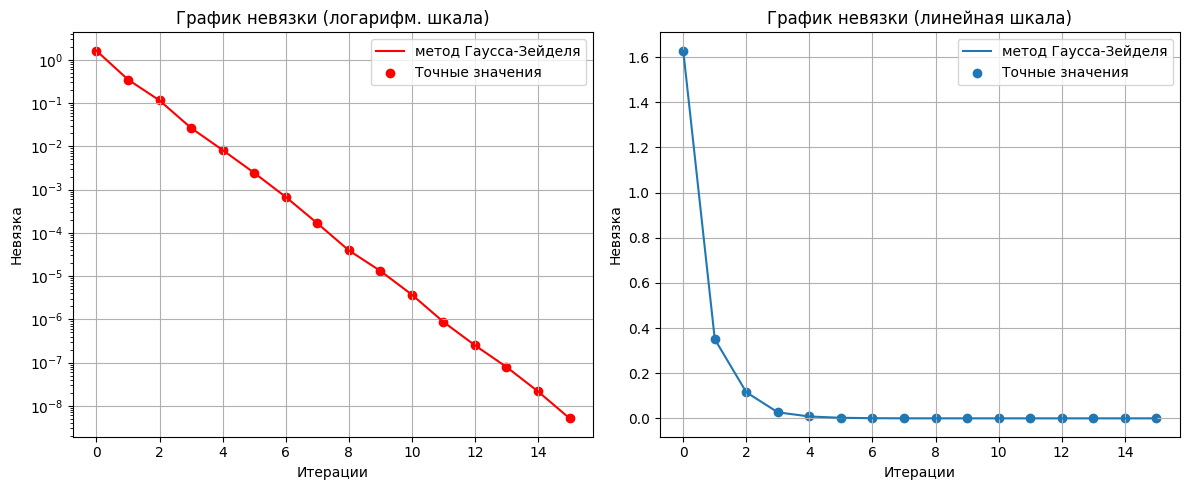

In [583]:
# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.10134986346905824

Точное решение: [ 0.0366026   0.08243786  0.05670121  0.14228675 -0.00180611  0.14198492
  0.07127987  0.05559748]

Итерационное решение [ 0.03660259  0.08243786  0.05670121  0.14228676 -0.00180611  0.14198492
  0.07127987  0.05559748]

Разница итерационного и точного решений: [3.52998848e-09 1.61418874e-09 2.12133420e-09 3.06910170e-09
 6.76588148e-10 5.25627042e-10 1.63460454e-09 2.88229524e-10]



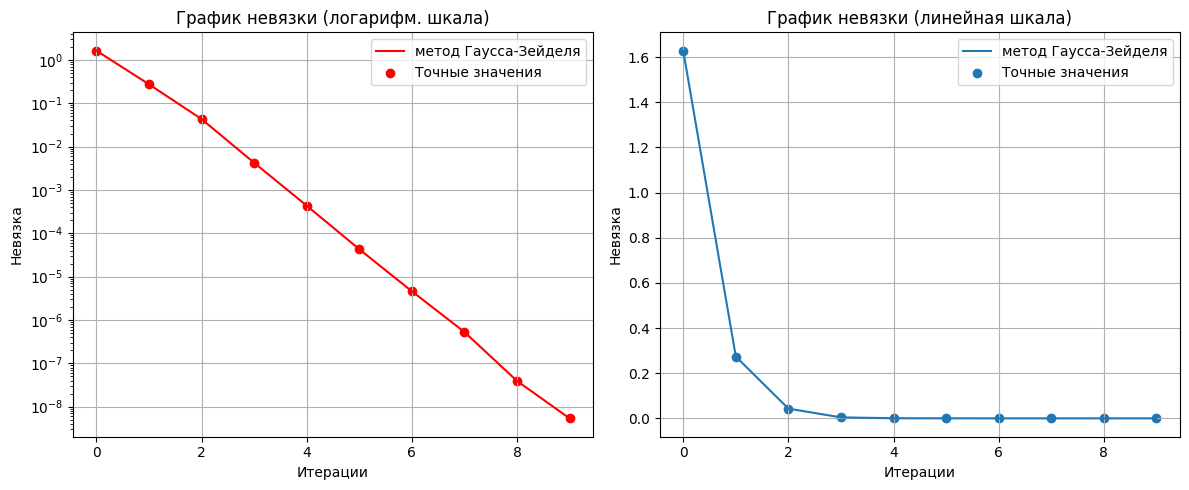

In [584]:
# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя')
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

Как мы можем наблюдать, необходимое количество итераций в обоих методах увеличилось, после уменьшения диагональных элементов. 

##### (c) Сходимость для положительно определённой матрицы $A = B^TB + \alpha I$ при $n = 500$.

In [585]:
# Генерация матрицы A = B^T * B + αI
n = 500
B = np.random.randn(n, n)
A = B.T @ B + 0.1 * np.eye(n)
for i in range(n):
    row_sum = np.sum(np.abs(A[i])) - np.abs(A[i, i])
    A[i, i] = row_sum + 0.0001

b = np.random.rand(n)

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 11

Максимальное по модулю собственное число матрицы B: 0.02824155554413037



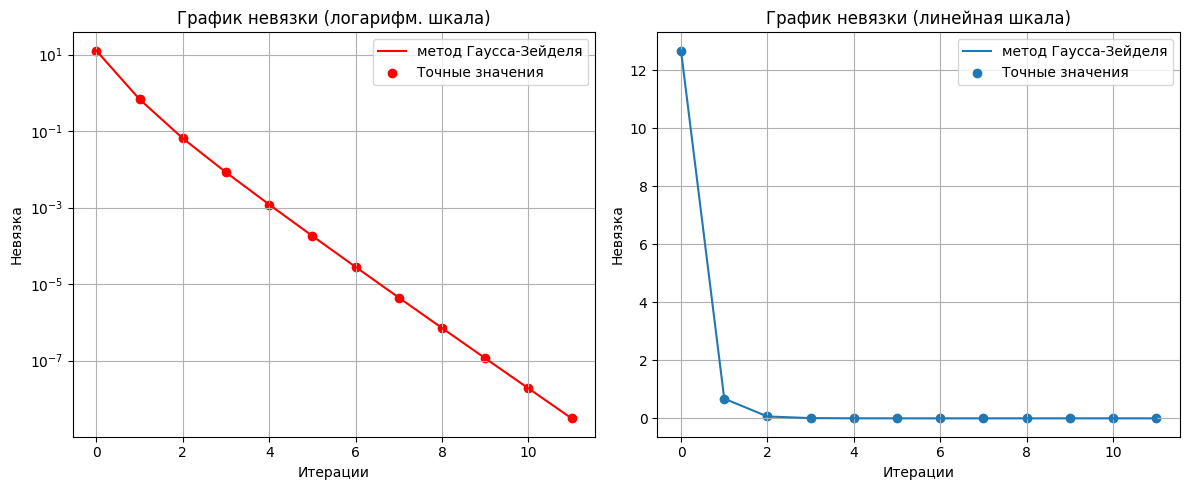

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 6

Максимальное по модулю собственное число матрицы B: 0.02824155554413037



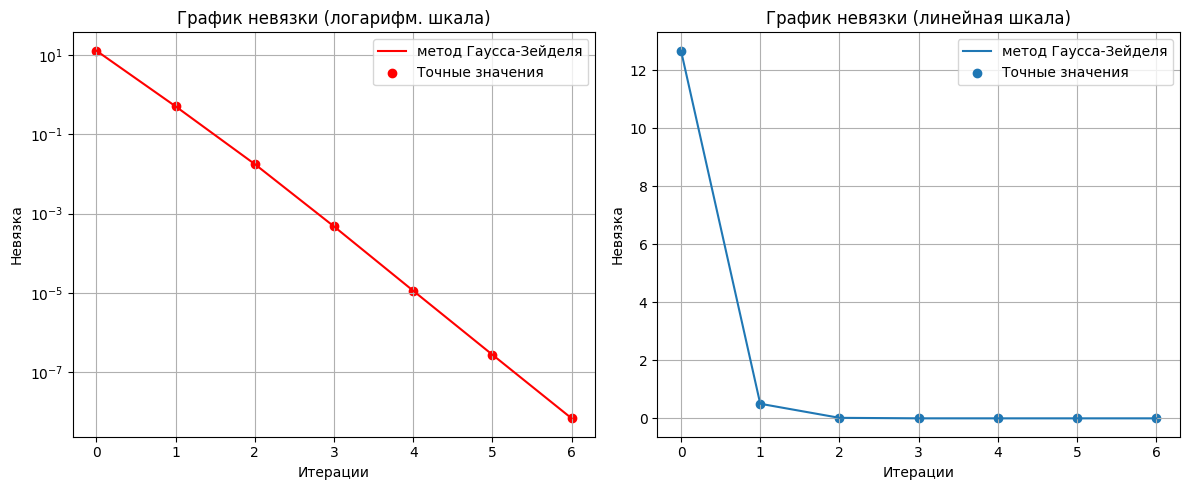

In [586]:
# Применяем метод Якоби
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)

# Cтатистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби', only_iter_and_eigenvals=True)
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Якоби')


# Применяем метод Гаусса-Зейделя
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)

# Статистика и графики невязки
write_statistics(A, b, iter_x, iterations_amount, 'метод Гаусса-Зейделя', only_iter_and_eigenvals=True)
discrepancy_vs_iteration(history[:, 0], history[:, 1], 'метод Гаусса-Зейделя')

### (3) Исследование влияния начального приближения $x^{(0)}$

Исследуем влияние начально приближения и построим графики зависимости евклидовой нормы ошибки $\|x^{k} - x^*\|_2$ от $k$:

**(a)** $x^{(0)}$ = 0

**(b)** $x^{(0)}$ - случайный вектор, $\|x^{(0)}\|_2$ = 1

**(c)** $x^{(0)}$ близок к точному решению $x^{*}$.

##### (a) Начальное приближение $x^{(0)}$ = 0.

In [587]:
A = np.array([
    [10, 2, 1, 1, 0],
    [2, 11, 1, 0, 1],
    [1, 1, 10, 2, 1],
    [1, 0, 2, 11, 1],
    [0, 1, 1, 1, 10]
])
b = np.array([15, 13, 16, 17, 14])

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 24

Максимальное по модулю собственное число матрицы B: 0.0928487357093806



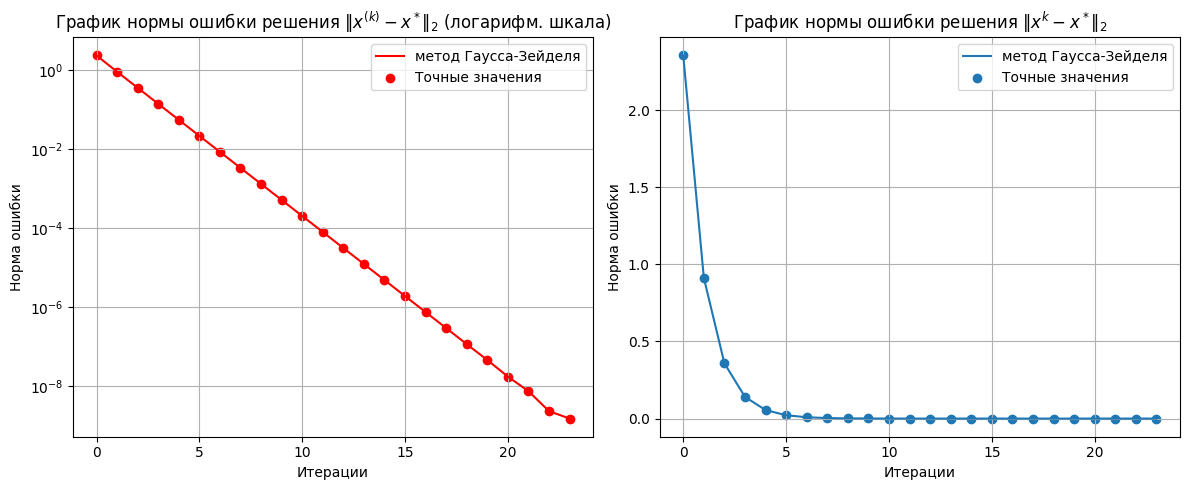

In [588]:
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, only_iter_and_eigenvals=True, method="метод Якоби")
x_k_vs_true_x(history, x_history, method="Метод Якоби")

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 9

Максимальное по модулю собственное число матрицы B: 0.0928487357093806



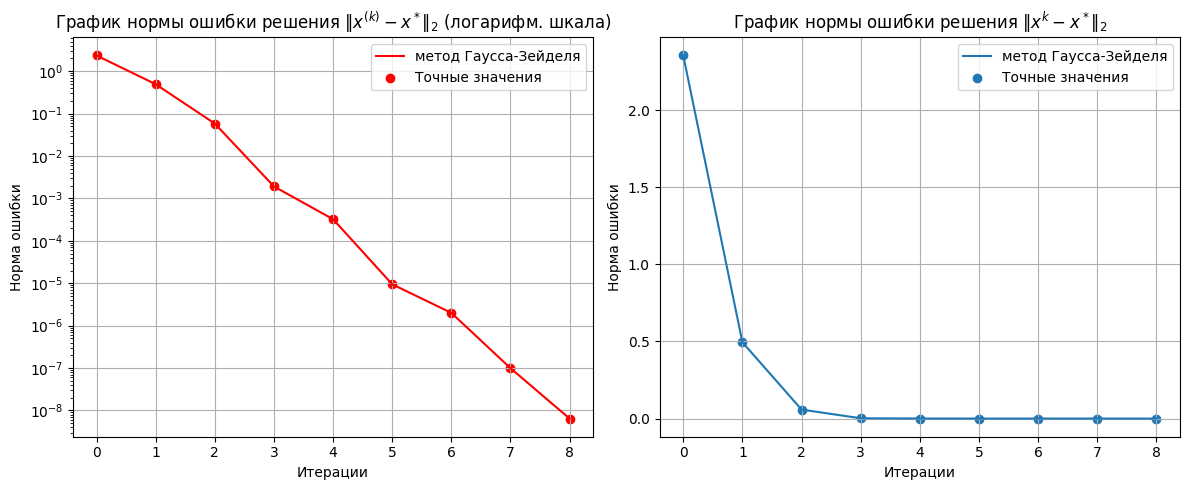

In [589]:
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, only_iter_and_eigenvals=True, method="метод Гаусса-Зейделя")
x_k_vs_true_x(history, x_history, method="Метод Гаусса-Зейделя")

##### (b)  $x^{(0)}$ - случайный вектор, $\|x^{(0)}\|_2$ = 1

In [590]:
A = np.array([
    [7, -2, 1, 0, 2],
    [-2, 8, 2, 1, -1],
    [1, 2, 9, -1, 1],
    [0, 1, -1, 7, 2],
    [2, -1, 1, 2, 8]
])
b = np.array([7, -4, 12, 9, 3])
x0 = np.random.randn(5)
x0 /= np.linalg.norm(x0) # Нормируем вектор

print(r"Начальное приближение x0:", x0, end='\n\n')

Начальное приближение x0: [ 0.5914308  -0.35844876  0.0654251  -0.03552377  0.71845787]



-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 32

Максимальное по модулю собственное число матрицы B: 0.264222093949406

Точное решение: [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Итерационное решение [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Разница итерационного и точного решений: [3.57111896e-10 8.99946340e-10 7.68106245e-10 8.02020006e-10
 5.99648775e-10]



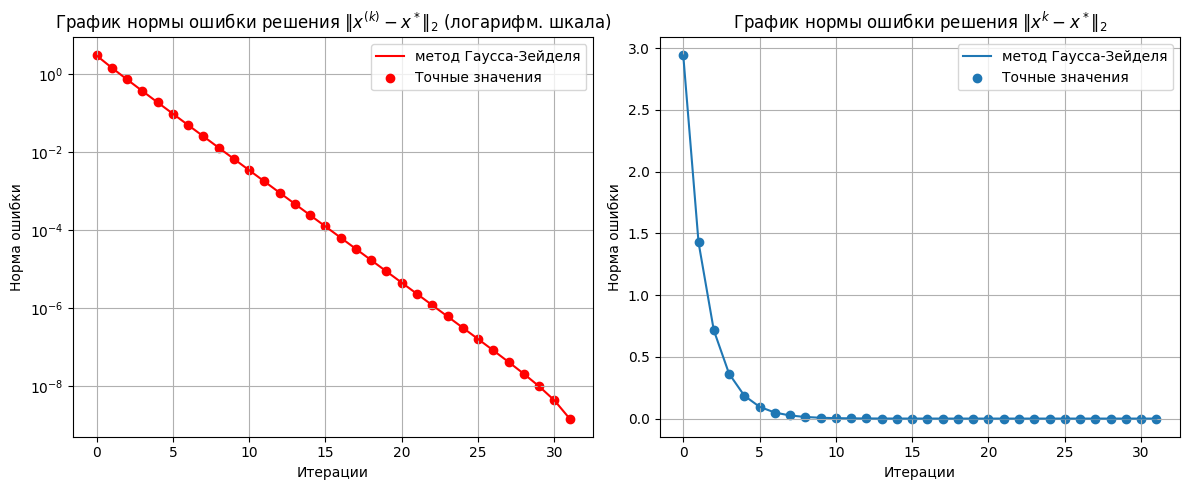

In [591]:
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method="метод Якоби")
x_k_vs_true_x(history, x_history, method="метод Якоби")

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 17

Максимальное по модулю собственное число матрицы B: 0.264222093949406

Точное решение: [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Итерационное решение [ 0.60147264 -1.10614855  1.78754165  1.87197678 -0.60507363]

Разница итерационного и точного решений: [2.16170337e-09 4.70792294e-10 3.86772836e-11 5.88681992e-10
 6.33582076e-10]



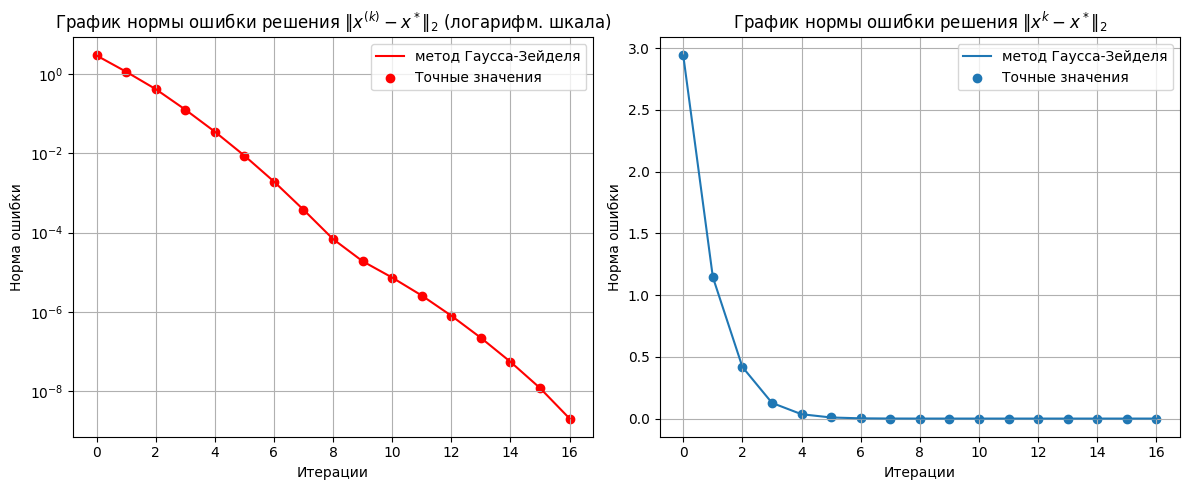

In [592]:
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method="метод Гаусса-Зейделя")
x_k_vs_true_x(history, x_history, method="метод Гаусса-Зейделя")

##### (c) $x^{(0)}$ близок к точному решению $x^{*}$.

In [593]:
A = np.array([
    [12, 3, 2, 0, 1],
    [3, 13, 2, 2, 0],
    [2, 2, 14, 3, 1],
    [0, 2, 3, 15, 2],
    [1, 0, 1, 2, 16]
])
b = np.array([30, 28, 35, 38, 40])
true_x = np.linalg.solve(A, b)
x0 = true_x + 0.005 * np.random.randn(5)
print("Начальное приближение x0:", x0)

Начальное приближение x0: [1.7650169  1.23377091 1.54336984 1.78018966 2.06969365]


-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 32

Максимальное по модулю собственное число матрицы B: 0.11126535564702218

Точное решение: [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Итерационное решение [1.76160774 1.23566183 1.54159776 1.78418873 2.07052606]

Разница итерационного и точного решений: [1.79309456e-10 1.93793204e-10 1.90187643e-10 1.54865454e-10
 8.70894468e-11]



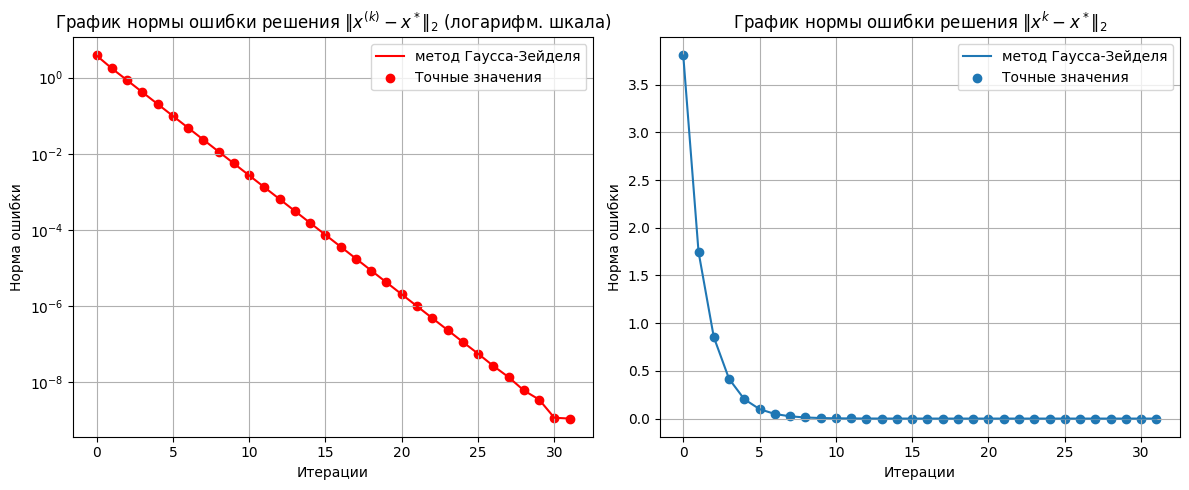

In [594]:
iter_x, history, x_history, iterations_amount = jacoby_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method='метод Якоби')
x_k_vs_true_x(history, x_history, method='метод Якоби')

-----------------------------------
СТАТИСТИКА (метод Гаусса-Зейделя):
-----------------------------------

Количество итераций: 11

Максимальное по модулю собственное число матрицы B: 0.11126535564702218

Точное решение: [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Итерационное решение [1.76160774 1.23566183 1.54159776 1.78418873 2.07052607]

Разница итерационного и точного решений: [2.37518738e-09 1.06080478e-10 8.38694891e-10 3.59640984e-10
 1.40985890e-10]



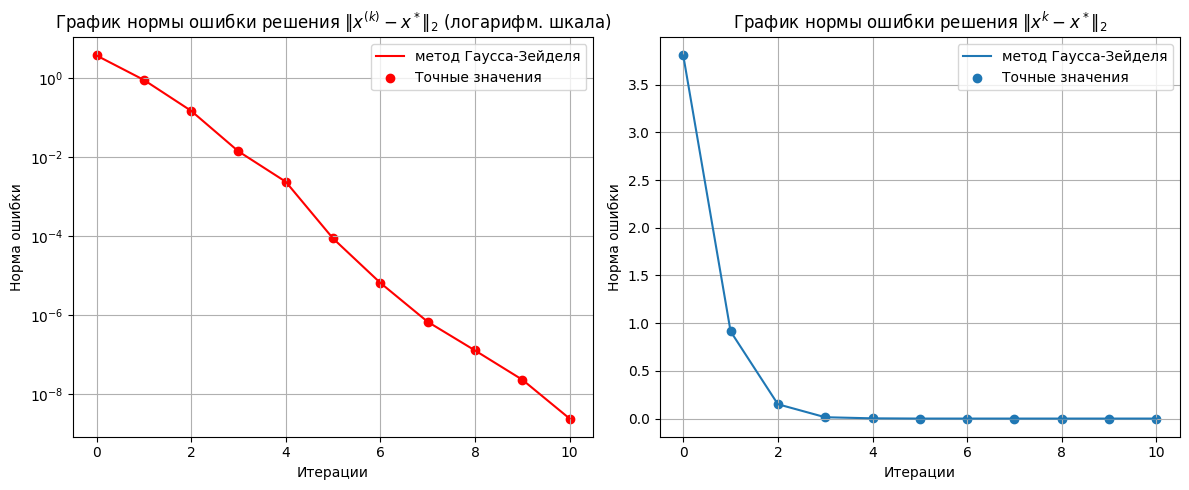

In [595]:
iter_x, history, x_history, iterations_amount = gauss_seidel_method(A, b, max_iteration=1000)
write_statistics(A, b, iter_x, iterations_amount, method='метод Гаусса-Зейделя')
x_k_vs_true_x(history, x_history, method='метод Гаусса-Зейделя')

# Нелинейные уравнения

- метод Ньютона
- метод одной касательной
- метод секущих

### (1) Методы решения

##### Метод Ньютона

In [596]:
def newton(x0: float, f: Callable, df: Callable,
           tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод Ньютона решения нелинейных уравнений """
  x = x0

  if history is not None: history.append(x)

  for i in range(max_iter):

    if df(x) == 0: return 0

    x = x - f(x)/df(x)

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

##### Метод одной касательной

In [597]:
def tangent(x0: float, f: Callable, df: float|Callable,
            tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод одной касательной решения нелинейных уравнений """
  df_x0 = df(x0) if callable(df) else df

  if df_x0 == 0: raise ValueError("Производная в точке x0 равна 0!")

  x = x0

  if history is not None: history.append(x)

  for i in range(max_iter):
    x = x - f(x)/df_x0

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

##### Метод секущих

In [598]:
def secant(x0: float, x1: float, f: Callable,
           tol=1e-6, max_iter=1000, history=None) -> float:
  """ Метод секущих решения нелинейных уравнений """
  x_a, x_b = x0, x1

  if history is not None: history.extend([x0, x1])

  for i in range(max_iter):
    if (f(x_b) - f(x_a)) == 0: return 0

    x = x_b - f(x_b)*(x_b - x_a)/(f(x_b) - f(x_a))
    x_a, x_b = x_b, x

    if history: history.append(x)

    if np.abs(f(x)) < tol:
      x = round(x, abs(int(np.log10(tol))))
      break

  return x

- Метод **Ньютона** имеет ***квадратичную*** сходимость
- Метод **одной касательной** имеет ***линейную*** сходимость
- Метод **секущих** имеет ***сверхлинейную*** сходимость

### (2-3) Тестирующие функции 

##### (2) Тестирование на функциях

In [599]:
def experiment_test(formula: str, f: Callable, df: Callable, 
                    newton_x0: float, tangent_x0: float, 
                    secant_x0: float, secant_x1: float):
    """ Численные эксперименты на функциях """
    
    display(Markdown("Численные эксперименты на функциях"))
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Метод Ньютона
    history = []
    x_newton = newton(newton_x0, f, df, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax1.plot(x_axis, y_axis, marker='o', color='r')
    ax1.set_title("Метод Ньютона")
    ax1.set_ylabel("|f(x)|")
    ax1.set_xlabel("iteration")
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.grid(True)

    # Метод одной касательной
    history = []
    x_tangent = tangent(tangent_x0, f, df, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax2.plot(x_axis, y_axis, marker='o', color='b')
    ax2.set_title("Метод одной касательной")
    ax2.set_ylabel("|f(x)|")
    ax2.set_xlabel("iteration")
    ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.grid(True)

    # Метод секущих
    history = []
    x_secant = secant(secant_x0, secant_x1, f, history=history)
    x_axis = np.array(range(len(history)))
    y_axis = np.abs(f(np.array(history)))
    ax3.plot(x_axis, y_axis, marker='o', color='g')
    ax3.set_title("Метод секущих")
    ax3.set_ylabel("|f(x)|")
    ax3.set_xlabel("iteration")
    ax3.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax3.grid(True)

    display(Math(f'x_N \\approx {x_newton}'))
    display(Math(f'x_T \\approx {x_tangent}'))
    display(Math(f'x_S \\approx {x_secant}'))

    plt.suptitle(formula)
    plt.tight_layout()
    plt.show()

##### (3) Чувствительность к начальному приближению

In [600]:
def experiment_start(formula: str, f: Callable, df: Callable, 
                     newton_x0_range, tangent_x0_range,
                    secant_x0_range, secant_x1:float, 
                    secant_x0: float, secant_x1_range):
    
    """ Чувствительность методов к начальному приближению """
    
    display(Markdown("Чувствительность методов к начальному приближению"))
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

    # Метод Ньютона
    newton_iters = []
    for x0 in newton_x0_range:
        history = []
        newton(x0, f, df, tol=1e-10, history=history)
        newton_iters.append(len(history))

    ax1.plot(newton_x0_range, newton_iters, 'ro-', markersize=4)
    ax1.set_title("Метод Ньютона")
    ax1.set_xlabel("x0")
    ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax1.set_ylabel("Число итераций")
    ax1.grid(True)

    # Метод касательной
    tangent_iters = []
    for x0 in tangent_x0_range:
        history = []
        tangent(x0, f, df, tol=1e-10, history=history)
        tangent_iters.append(len(history))

    ax2.plot(tangent_x0_range, tangent_iters, 'bo-', markersize=4)
    ax2.set_title("Метод Касательной")
    ax2.set_xlabel("x0")
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.set_ylabel("Число итераций")
    ax2.grid(True)

    # Метод cекущих - зависимость от первого
    secant_iters_x0 = []
    for x0 in secant_x0_range:
        history = []
        secant(x0, secant_x1, f, tol=1e-10, history=history)
        secant_iters_x0.append(len(history))

    ax3.plot(secant_x0_range, secant_iters_x0, 'go-', markersize=4)
    ax3.set_title("Метод Секущих (зависимость от x0)")
    ax3.set_xlabel("x0")
    ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax3.set_ylabel("Число итераций")
    ax3.grid(True)

    # Метод cекущих - зависимость от второго
    secant_iters_x1 = []
    for x1 in secant_x1_range:
        history = []
        secant(secant_x0, x1, f, tol=1e-10, history=history)
        secant_iters_x1.append(len(history))

    ax4.plot(secant_x1_range, secant_iters_x1, 'yo-', markersize=4)
    ax4.set_title("Метод Секущих (зависимость от x1)")
    ax4.set_xlabel("x1")
    ax4.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax4.set_ylabel("Число итераций")
    ax4.grid(True)


    plt.suptitle(f"Сравнение методов для {formula}")
    plt.tight_layout()
    plt.show()

### Считаем производные аналитически

In [601]:
def derivative(f: sp.Expr, x: sp.Symbol):
  """ Символьно вычисляет производную """
  df = sp.Derivative(f, x)
  display(sp.Eq(df, df.doit(), evaluate=False))

In [602]:
x = sp.symbols('x')
derivative(x**2 - 2, x)
derivative(sp.cos(x)  - x, x)
derivative(sp.exp(-x) - x, x)

Eq(Derivative(x**2 - 2, x), 2*x)

Eq(Derivative(-x + cos(x), x), -sin(x) - 1)

Eq(Derivative(-x + exp(-x), x), -1 - exp(-x))

### $f(x) = x^2 - 2$

In [603]:
x = np.linspace(-10, 10, 200)
f = lambda x: x**2 - 2

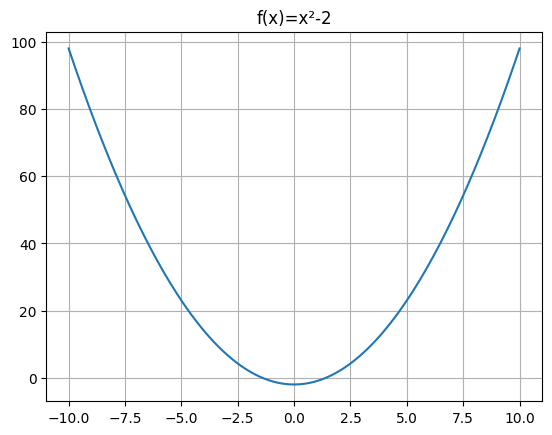

In [604]:
plt.plot(x, f(x))
plt.title("f(x)=x²-2")
plt.grid(True)
plt.show()

Численные эксперименты на функциях

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

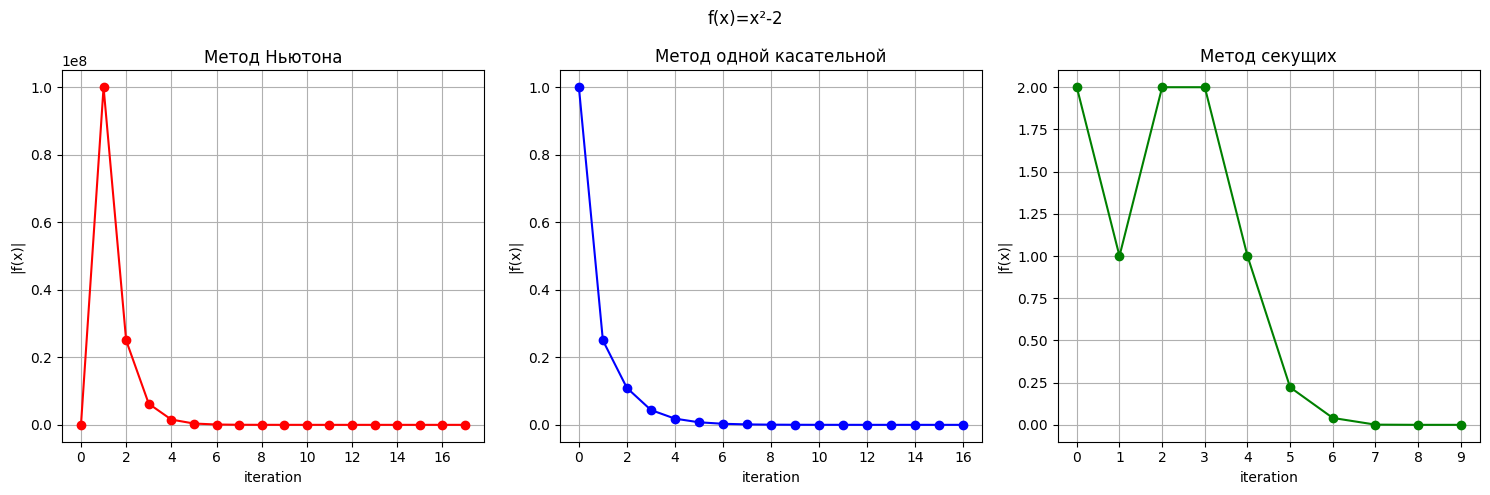

In [605]:
experiment_test(
    formula="f(x)=x²-2",
    f = lambda x: x**2 - 2,
    df = lambda x: 2*x,
    newton_x0 = 1e-4,
    tangent_x0 = -1,
    secant_x0 = -2,
    secant_x1 = 1
)

Чувствительность методов к начальному приближению

C:\Users\User\AppData\Local\Temp\ipykernel_3124\1586228330.py:3: RuntimeWarning: overflow encountered in scalar power
  f = lambda x: x**2 - 2,


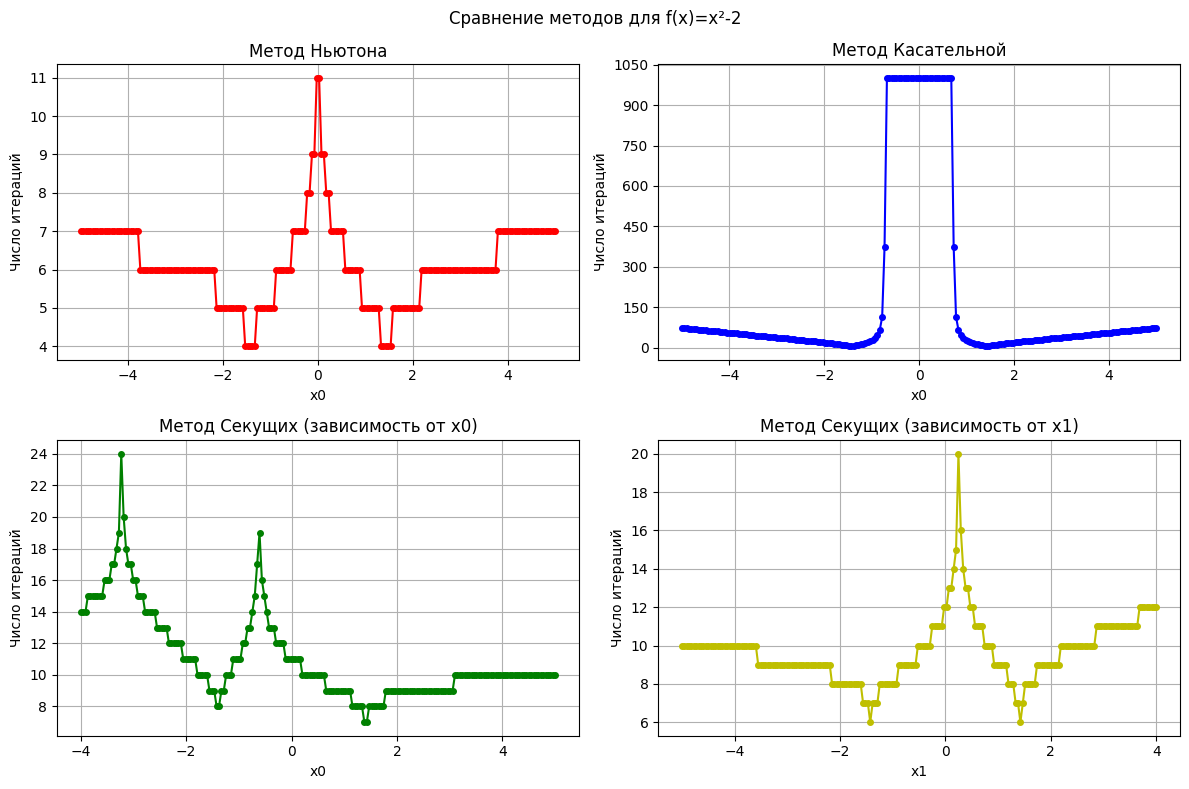

In [606]:
experiment_start(
    formula="f(x)=x²-2",
    f = lambda x: x**2 - 2,
    df = lambda x: 2*x,
    newton_x0_range = np.linspace(-5, 5, 200),
    tangent_x0_range = np.linspace(-5, 5, 200),
    secant_x0_range = np.linspace(-4, 4.999, 200),
    secant_x1 = 5,
    secant_x0 = -5,
    secant_x1_range = np.linspace(-4.999, 4, 200)
)

### $f(x) = \cos{x} - x$

In [607]:
x = np.linspace(-10, 10, 200)
f = lambda x: np.cos(x) - x

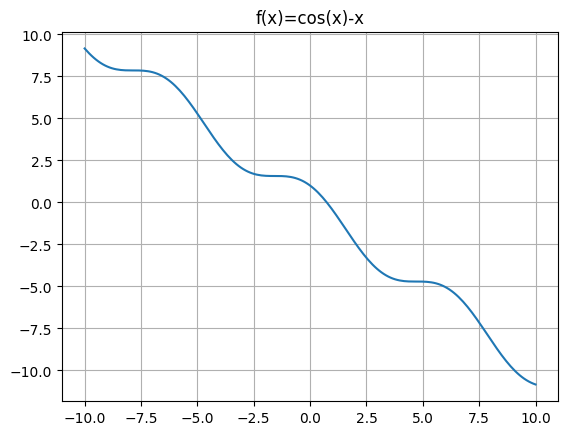

In [608]:
plt.plot(x, f(x))
plt.title("f(x)=cos(x)-x")
plt.grid(True)
plt.show()

Численные эксперименты на функциях

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

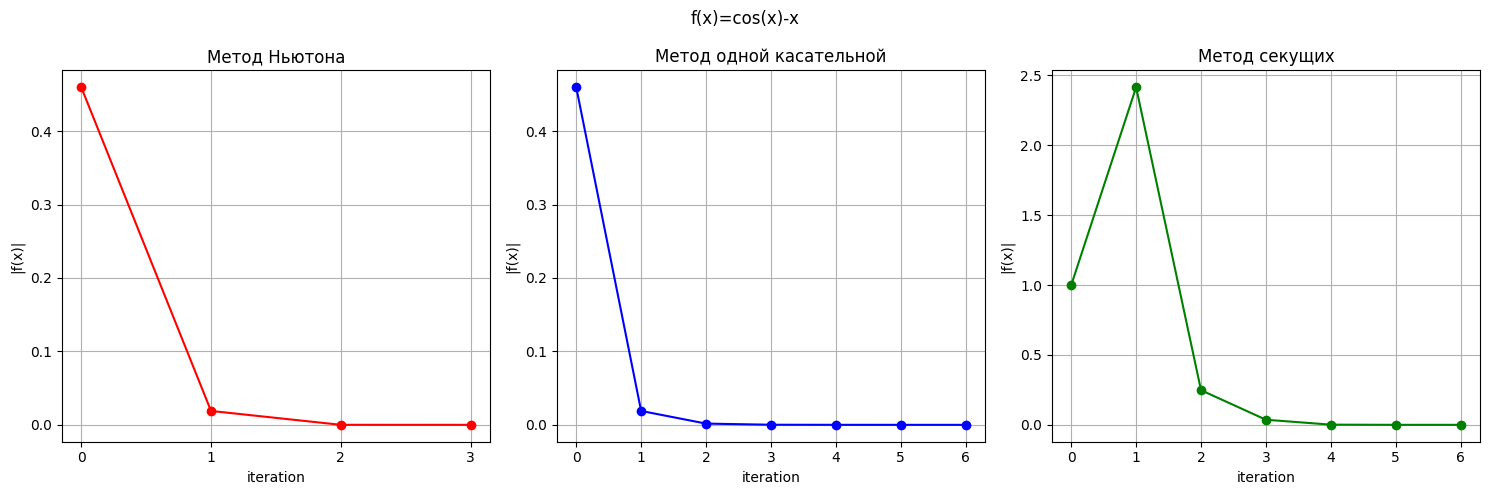

In [609]:
experiment_test(
    formula="f(x)=cos(x)-x",
    f = lambda x: np.cos(x) - x,
    df = lambda x: -np.sin(x) - 1,
    newton_x0 = 1,
    tangent_x0 = 1,
    secant_x0 = 1e-4,
    secant_x1 = 2
)

Чувствительность методов к начальному приближению

C:\Users\User\AppData\Local\Temp\ipykernel_3124\1412486634.py:13: RuntimeWarning: overflow encountered in scalar divide
  x = x - f(x)/df_x0
C:\Users\User\AppData\Local\Temp\ipykernel_3124\3989532054.py:3: RuntimeWarning: invalid value encountered in cos
  f = lambda x: np.cos(x) - x,


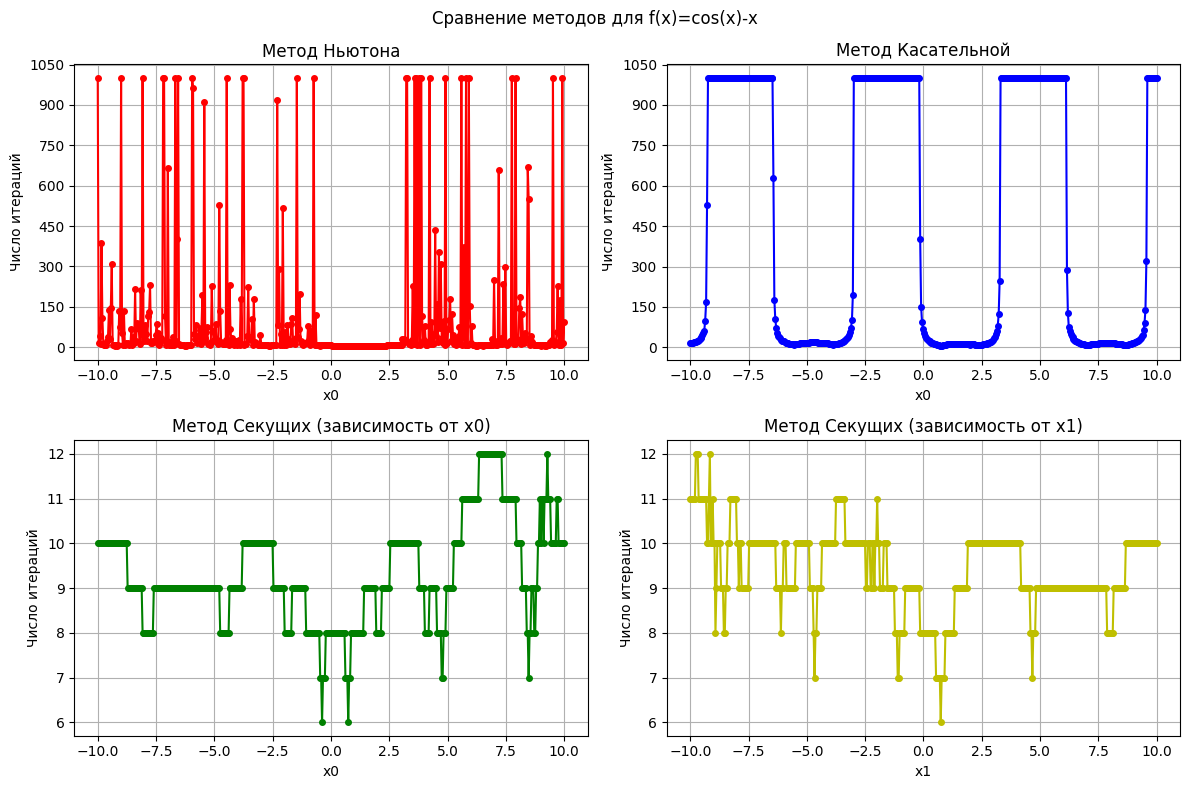

In [610]:
experiment_start(
    formula="f(x)=cos(x)-x",
    f = lambda x: np.cos(x) - x,
    df = lambda x: -np.sin(x) - 1,
    newton_x0_range = np.linspace(-10, 10, 500),
    tangent_x0_range = np.linspace(-10, 10, 500),
    secant_x0_range = np.linspace(-10, 10, 500),
    secant_x1 = 10.001,
    secant_x0 = -10.001,
    secant_x1_range = np.linspace(-10, 10, 500)
)

### $f(x) = e^{-x} - x$

In [611]:
x = np.linspace(-2, 10, 200)
f = lambda x: np.exp(-x) - x

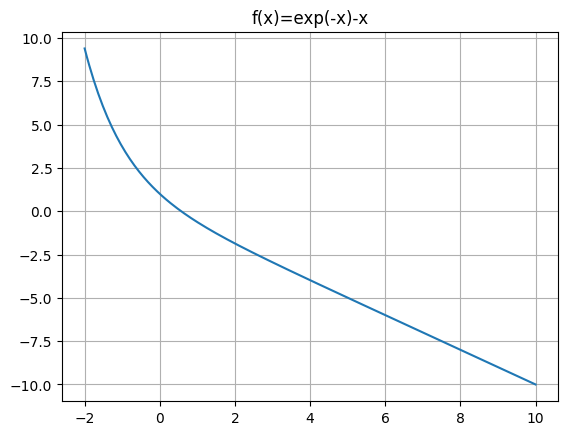

In [612]:
plt.plot(x, f(x))
plt.title("f(x)=exp(-x)-x")
plt.grid(True)
plt.show()

Численные эксперименты на функциях

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

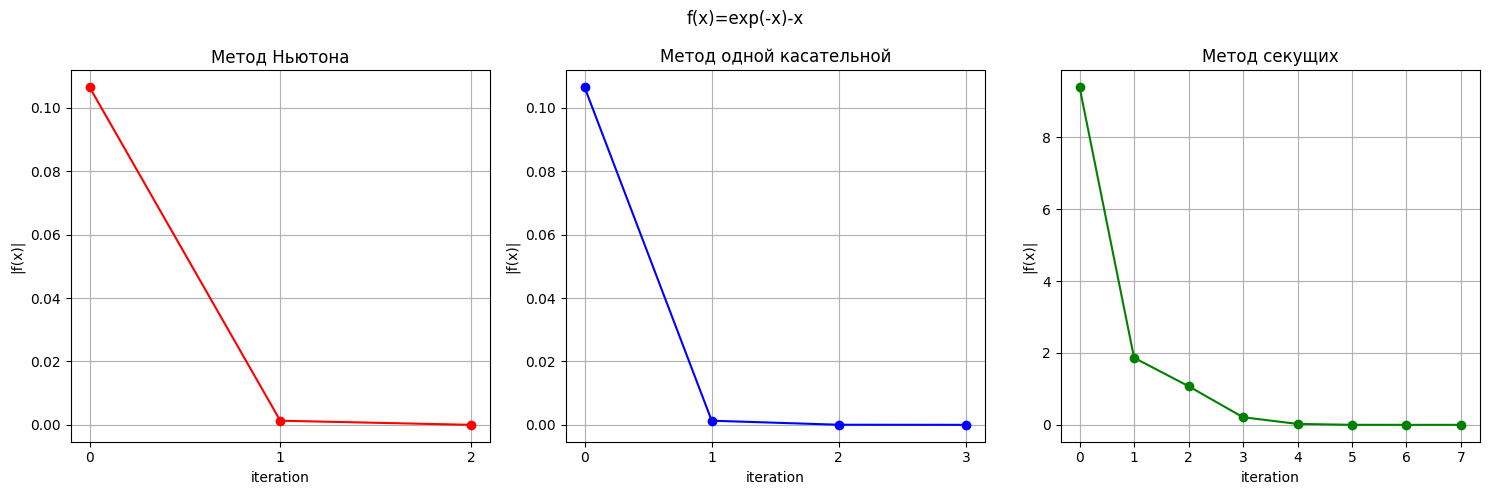

In [613]:
experiment_test(
    formula="f(x)=exp(-x)-x",
    f = lambda x: np.exp(-x) - x,
    df = lambda x: -np.exp(-x) - 1,
    newton_x0 = 0.5,
    tangent_x0 = 0.5,
    secant_x0 = -2,
    secant_x1 = 2,
)

Чувствительность методов к начальному приближению

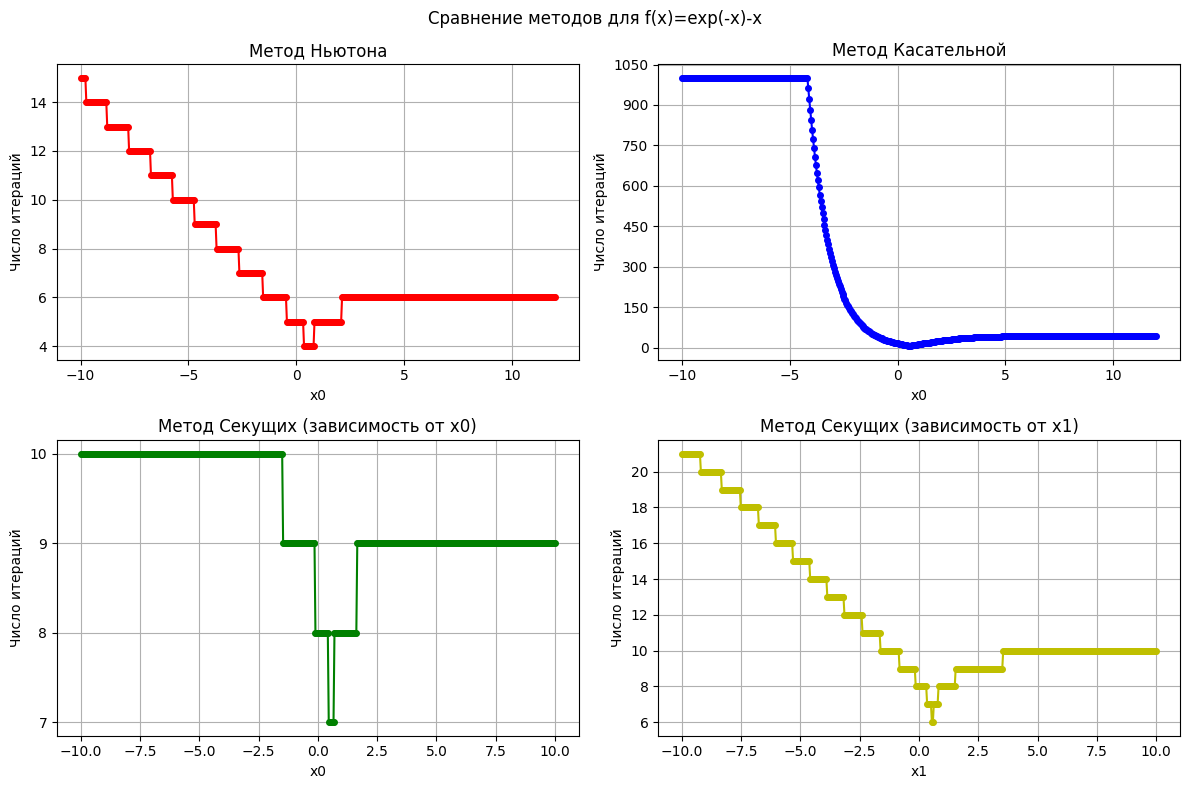

In [614]:
experiment_start(
    formula="f(x)=exp(-x)-x",
    f = lambda x: np.exp(-x) - x,
    df = lambda x: -np.exp(-x) - 1,
    newton_x0_range = np.linspace(-10, 12, 500),
    tangent_x0_range = np.linspace(-10, 12, 500),
    secant_x0_range = np.linspace(-10, 10, 500),
    secant_x1 = 10.001,
    secant_x0 = -10.001,
    secant_x1_range = np.linspace(-10, 10, 500)
)

# Нелинейные системы

- многомерный метод Ньютона

### (5) Многомерный метод Ньютона

In [615]:
def multi_newton(x0, F, J, max_iter=10000, tol=1e-4, history=None):
  """ Многомерный метод Ньютона """
  x = x0.copy()

  if history is not None: history.append(x.copy())

  for i in range(max_iter):
    F_val = np.array(F(*x)).flatten()
    J_val = np.array(J(*x))

    p = np.linalg.solve(J_val, F_val) # TODO: заменить на самописный метод
    x -= p

    if history: history.append(x.copy())

    if np.linalg.norm(F_val) < tol:
      return x

  print(f"Не сошёлся за {max_iter} итераций!")
  return x

### Вывод истории

In [616]:
def display_history(history):
  """ Визуализация истории итераций метода Ньютона """
  iters = list(range(len(history)))
  hx = [history[i][0] for i in range(len(history))]
  hy = [history[i][1] for i in range(len(history))]

  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

  ax1.plot(iters, hx, 'ro-')
  ax1.set_title("Переменная x")
  ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax1.set_xlabel("Число итераций")
  ax1.grid(True)

  ax2.plot(iters, hy, 'bo-')
  ax2.set_title("Переменная y")
  ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax2.set_xlabel("Число итераций")
  ax2.grid(True)

  ax3.plot(hx, hy, 'go--')
  ax3.set_title("Точки (x, y)")
  ax3.set_xlabel("x")
  ax3.set_ylabel("y")
  ax3.grid(True)

  ax3.annotate('', xy=(hx[1], hy[1]), xytext=(hx[0], hy[0]),
               arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

  plt.tight_layout()
  plt.show()

### Система (a)

$$
\begin{cases}
F_1(x, y) = \sin x + y^2 - 1 = 0,\\[6pt]
F_2(x, y) = x^2 - \cos y = 0.
\end{cases}
$$

##### Эталонные решения


|        x        |        y        |
| :-------------: | :-------------: |
| -0.569398449123 | -1.240614970431 |
| -0.569398449123 | +1.240614970431 |
| +0.953482427735 | -0.429608847958 |
| +0.953482427735 | +0.429608847958 |

##### Аналитическое (символьное) вычисление производных для Якобиан

In [617]:
x, y = sp.symbols('x y')

F = sp.Matrix([sp.sin(x) + y**2 - 1, x**2 - sp.cos(y)])

J = sp.Matrix([
  [sp.diff(F[0], x), sp.diff(F[0], y)],
  [sp.diff(F[1], x), sp.diff(F[1], y)]
])

display(Markdown("**Система уравнений F_a**"), F)
display(Markdown("**Матрица Якоби J_a**"), J)

F = sp.lambdify([x, y], F, 'numpy')
J = sp.lambdify([x, y], J, 'numpy')

**Система уравнений F_a**

Matrix([
[y**2 + sin(x) - 1],
[    x**2 - cos(y)]])

**Матрица Якоби J_a**

Matrix([
[cos(x),    2*y],
[   2*x, sin(y)]])

##### Тестирование

$x \approx 0.9534824277354988$

$y \approx 0.4296088479583021$

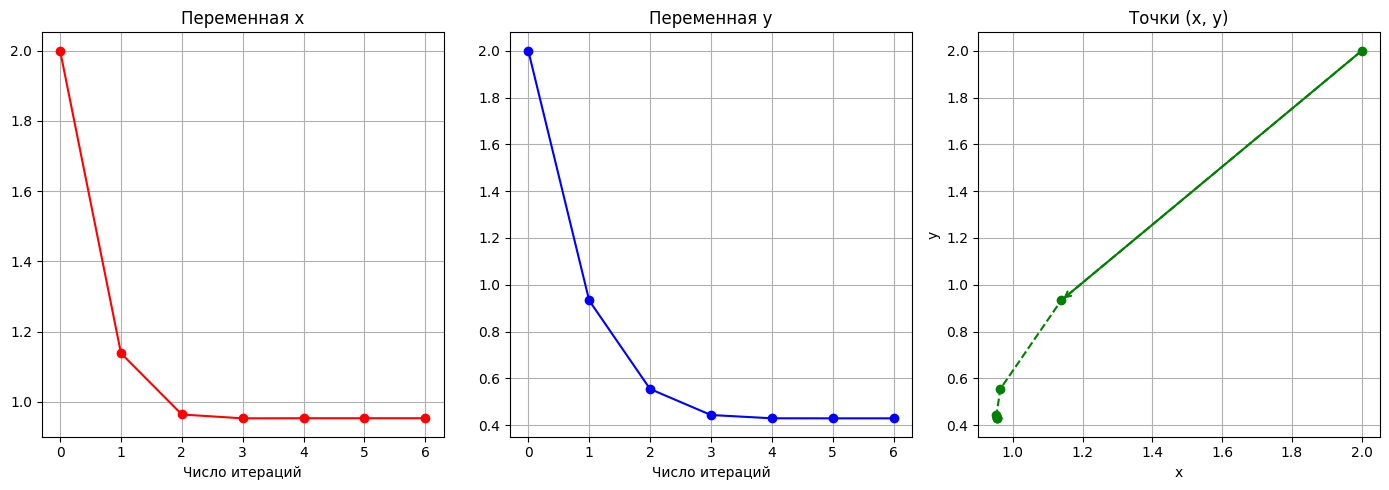

In [618]:
history = []
x = multi_newton(np.array([2, 2], float), F, J, history=history)

display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

##### Области сходимости

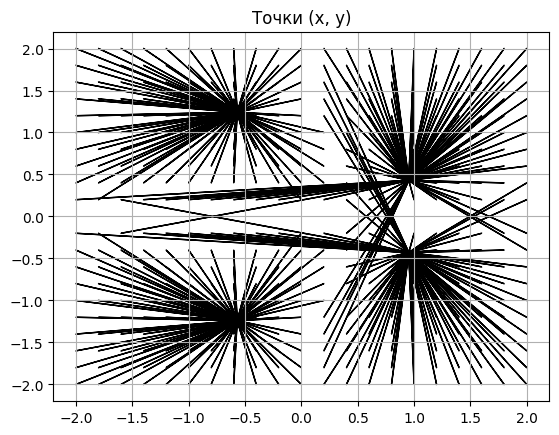

In [619]:
for x in np.linspace(-2, 2, 21):
  for y in np.linspace(-2, 2, 21):
    try:
      ax, ay = multi_newton(np.array([x, y], float), F, J)
      plt.arrow(x, y, ax-x, ay-y)

    except np.linalg.LinAlgError:
      continue

plt.title("Точки (x, y)")
plt.grid(True)
plt.show()

### Система (б)

$$
\begin{cases}
F_1(x, y) = x^2 + y^2 - 4 = 0,\\[6pt]
F_2(x, y) = e^x + y - 1 = 0.
\end{cases}
$$

##### Эталонные решения
|        x        |         y       |
| :-------------: | :-------------: |
| -1.816264068825 | +0.837367799891 |
| +1.004168738475 | -1.729637287026 |

##### Аналитическое (символьное) вычисление производных для Якобиан

In [620]:
x, y = sp.symbols('x y')

F = sp.Matrix([x**2 + y**2 - 4, sp.exp(x) + y - 1])

J = sp.Matrix([
  [sp.diff(F[0], x), sp.diff(F[0], y)],
  [sp.diff(F[1], x), sp.diff(F[1], y)]
])

display(Markdown("**Система уравнений F_b**"), F)
display(Markdown("**Матрица Якоби J_b**"), J)

F = sp.lambdify([x, y], F, 'numpy')
J = sp.lambdify([x, y], J, 'numpy')

**Система уравнений F_b**

Matrix([
[x**2 + y**2 - 4],
[ y + exp(x) - 1]])

**Матрица Якоби J_b**

Matrix([
[   2*x, 2*y],
[exp(x),   1]])

##### Тестирование

$x \approx -1.8162640688341276$

$y \approx 0.8373677998953689$

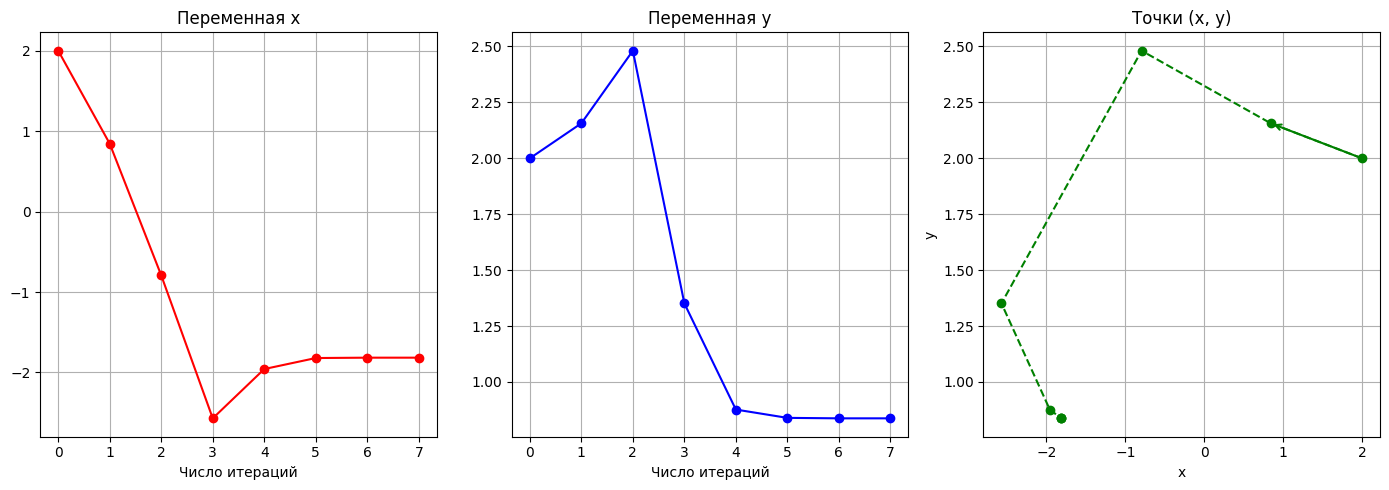

In [621]:
history = []
x = multi_newton(np.array([2, 2], float), F, J, history=history)

display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

##### Области сходимости

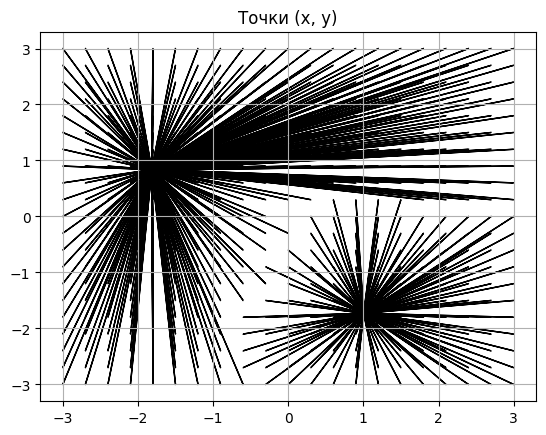

In [622]:
for x in np.linspace(-3, 3, 21):
  for y in np.linspace(-3, 3, 21):
    try:
      ax, ay = multi_newton(np.array([x, y], float), F, J)
      plt.arrow(x, y, ax-x, ay-y)

    except np.linalg.LinAlgError:
      continue

plt.title("Точки (x, y)")
plt.grid(True)
plt.show()

##### Исследование в точках $(-1, -1)$, $(0, 0)$, $(1, 1)$

В точке $(0, 0)$ Якобиан вырожден

$(x_0, y_0) = (-1, -1)$

$x \approx -1.8162640688251506$

$y \approx 0.8373677998912478$

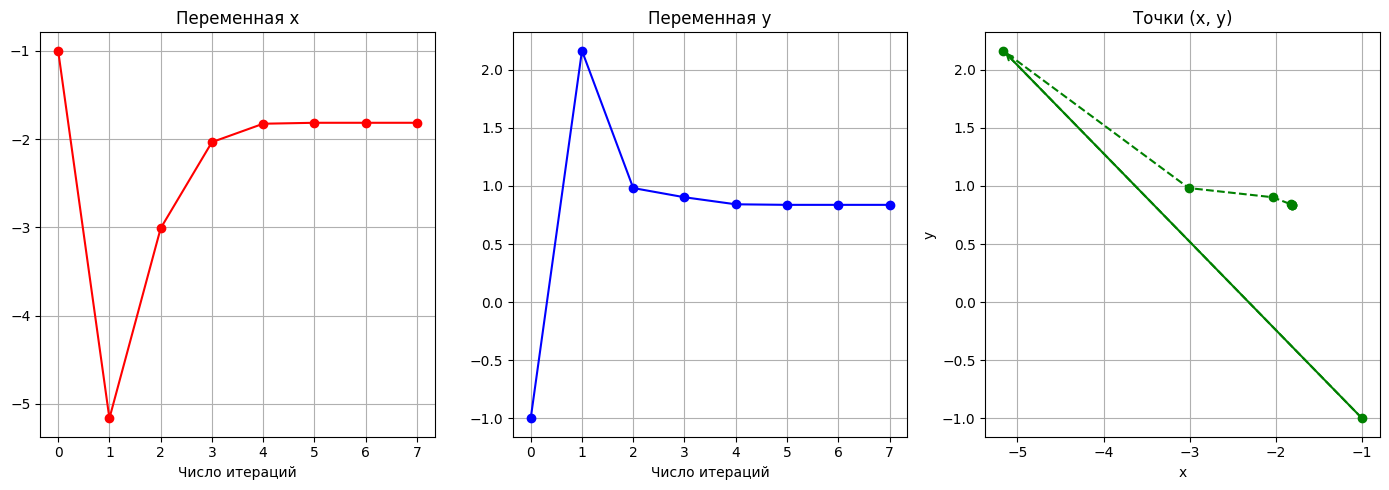

In [623]:
x_0, y_0 = -1, -1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

$(x_0, y_0) = (1, 1)$

$x \approx -1.8162640688252372$

$y \approx 0.8373677998912874$

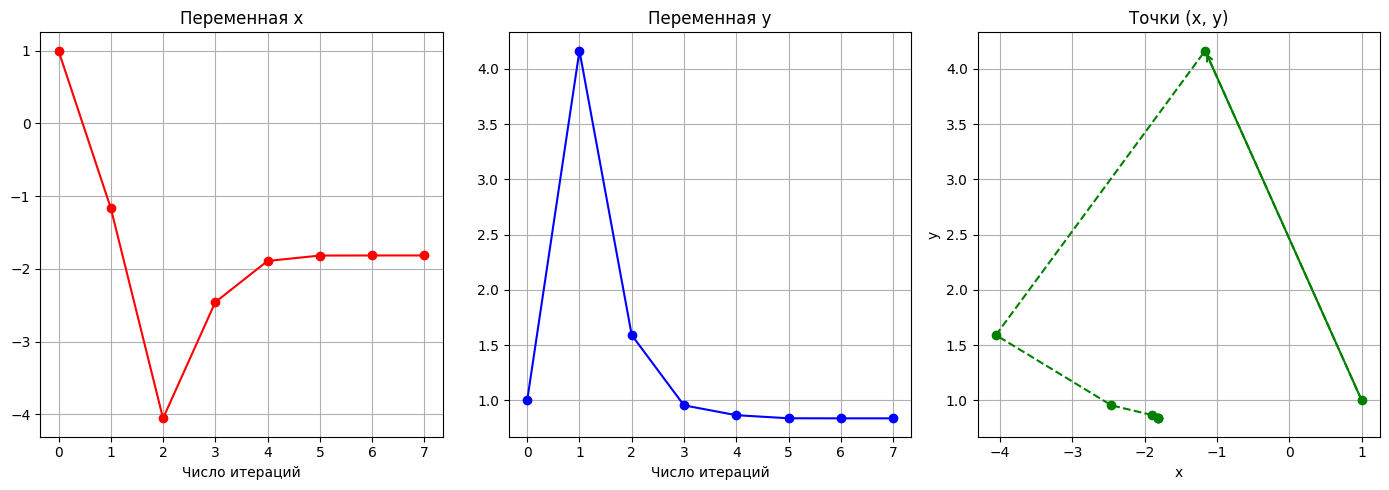

In [624]:
x_0, y_0 = 1, 1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

$(x_0, y_0) = (1, -1)$

$x \approx 1.0041687384746592$

$y \approx -1.72963728702587$

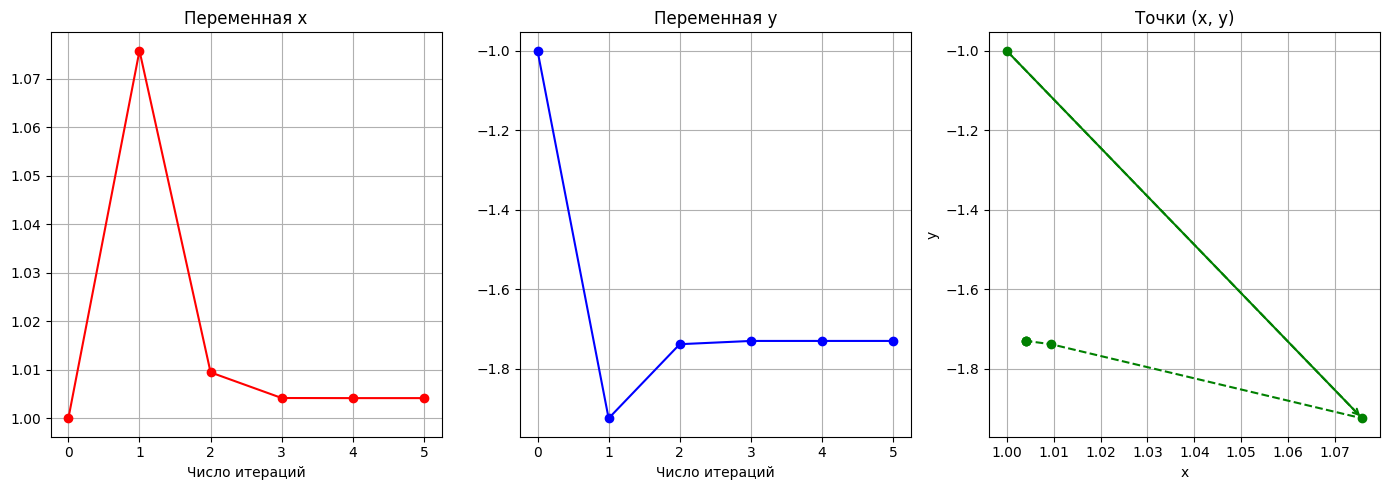

In [625]:
x_0, y_0 = 1, -1

history = []
x = multi_newton(np.array([x_0, y_0], float), F, J, history=history)

display(Markdown(f"$(x_0, y_0) = ({x_0}, {y_0})$"))
display(Markdown(f"$x \\approx {x[0]}$"), Markdown(f"$y \\approx {x[1]}$"))
display_history(history)

# Заключение